# Proyecto Análisis de Datos, Caso 2:
## Estudio sobre la calidad de aire en la Región Metropolitana de Santiago

En este proyecto, analizaremos los dataset de calidad de aire entregados por SINCA diariamente desde 2015 a 2025 en las comunas de Cerro Navia, El Bosque y Las Condes. 
Escogimos estas comunas para obtener una variación significativa en los datos (debido a lo diferente que son las comunas geográficamente), siendo nuestro único límite el de quedarse en Santiago, debido a que existían registros mas extensivos de esta ciudad.

Haremos un análisis descriptivo de los dataset, y luego, haremos un análisis inferencial para llegar a conclusiones significativas sobre los datos.  


requisitos proyecto:
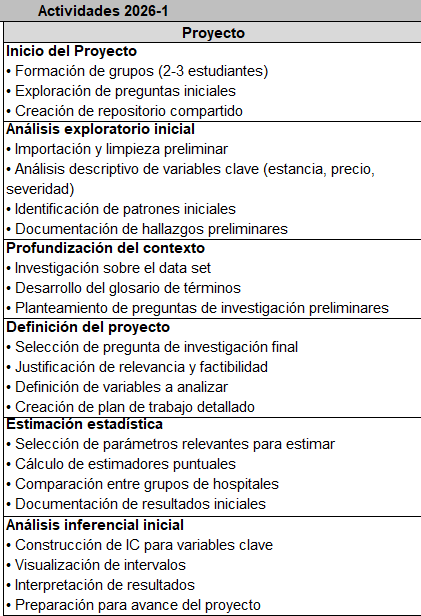

### Importar Librerías


In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

## Carga y limpieza de datos 

In [165]:
# Funciones para limpiar datos
def renamedb(df, column1, newcolumn1):
    ''' 
    Funcion para renombrar columna, con la antigua tomando el parametro 'column1' y el nuevo nombre de esta como 'newcolumn1'
    '''
    return df.rename(columns={f"{column1}":f"{newcolumn1}"})
    

Cerro Navia

In [166]:
naviaCO =pd.read_csv('Datos/cerro_navia/COCerroNavia.csv', sep=';', decimal=',')
display(naviaCO.head())
naviamp2_5 =pd.read_csv('Datos/cerro_navia/mp2.5CerroNavia.csv', sep=';', decimal=',')
display(naviamp2_5.head())
naviamp10 =pd.read_csv('Datos/cerro_navia/mp10CerroNavia.csv', sep=';', decimal=',')
display(naviamp10.head())
naviaNO2 =pd.read_csv('Datos/cerro_navia/NO2CerroNavia.csv', sep=';', decimal=',')
display(naviaNO2.head())
naviaNO =pd.read_csv('Datos/cerro_navia/NOCerroNavia.csv', sep=';', decimal=',')
display(naviaNO.head())
naviaNOx =pd.read_csv('Datos/cerro_navia/NOxCerroNavia.csv', sep=';', decimal=',')
display(naviaNOx.head())
naviaO3 =pd.read_csv('Datos/cerro_navia/O3CerroNavia.csv', sep=';', decimal=',')
display(naviaO3.head())



,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,0.311059,NaN,NaN,NaN
1,150102,0,0.313554,NaN,NaN,NaN
2,150103,0,0.453158,NaN,NaN,NaN
3,150104,0,0.382449,NaN,NaN,NaN
4,150105,0,0.338440,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,11.4167,NaN,NaN,NaN
1,150102,0,11.6250,NaN,NaN,NaN
2,150103,0,15.1250,NaN,NaN,NaN
3,150104,0,17.6250,NaN,NaN,NaN
4,150105,0,16.3333,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,23.3333,NaN,NaN,NaN
1,150102,0,32.6591,NaN,NaN,NaN
2,150103,0,44.2708,NaN,NaN,NaN
3,150104,0,41.6666,NaN,NaN,NaN
4,150105,0,40.8958,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,5.95460,NaN,NaN,NaN
1,150102,0,10.54060,NaN,NaN,NaN
2,150103,0,11.68920,NaN,NaN,NaN
3,150104,0,8.44757,NaN,NaN,NaN
4,150105,0,8.85443,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,3.01365,NaN,NaN,NaN
1,150102,0,4.77319,NaN,NaN,NaN
2,150103,0,5.52844,NaN,NaN,NaN
3,150104,0,1.76569,NaN,NaN,NaN
4,150105,0,4.07631,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,8.74979,NaN,NaN,NaN
1,150102,0,15.28440,NaN,NaN,NaN
2,150103,0,17.17250,NaN,NaN,NaN
3,150104,0,10.12400,NaN,NaN,NaN
4,150105,0,12.92000,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,19.7559,NaN,NaN,NaN
1,150102,0,24.4797,NaN,NaN,NaN
2,150103,0,25.1539,NaN,NaN,NaN
3,150104,0,29.8737,NaN,NaN,NaN
4,150105,0,23.4711,NaN,NaN,NaN


In [167]:
droppedcolumns = ["HORA (HHMM)", "Registros preliminares", "Registros no validados", "Unnamed: 5"]
def cleanNavia(df):

    df[["FECHA (YYMMDD)"]] = df[["FECHA (YYMMDD)"]].astype(str)
    df['FECHA (YYMMDD)'] = pd.to_datetime(df['FECHA (YYMMDD)'], format='%y%m%d')
    df2 = renamedb(df, "FECHA (YYMMDD)", "Fecha")
    df3 = df2.drop(droppedcolumns, axis=1, inplace=False)
    return df3                                                             

naviaCO = cleanNavia(naviaCO)
naviamp10 = cleanNavia(naviamp10)
naviamp2_5 = cleanNavia(naviamp2_5)
naviaNO2 = cleanNavia(naviaNO2)
naviaNO = cleanNavia(naviaNO)
naviaNOx = cleanNavia(naviaNOx)
naviaO3 = cleanNavia(naviaO3)

In [168]:
dfnavia = naviaCO
dfnavia = dfnavia.drop(["Registros validados"], axis=1, inplace=False)
dfnavia[['Fecha', 'CO']] = naviaCO[['Fecha', 'Registros validados']]
dfnavia[['MP10']] = naviamp10[['Registros validados']]
dfnavia[['MP2.5']] = naviamp2_5[['Registros validados']]
dfnavia[['NO2']] = naviaNO2[['Registros validados']]
dfnavia[['NO']] = naviaNO[['Registros validados']]
dfnavia[['NOx']] = naviaNOx[['Registros validados']]
dfnavia[['O3']] = naviaO3[['Registros validados']]

display(dfnavia)


,Fecha,CO,MP10,MP2.5,NO2,NO,NOx,O3
0,2015-01-01,0.311059,23.3333,11.4167,5.95460,3.01365,8.74979,19.7559
1,2015-01-02,0.313554,32.6591,11.6250,10.54060,4.77319,15.28440,24.4797
2,2015-01-03,0.453158,44.2708,15.1250,11.68920,5.52844,17.17250,25.1539
3,2015-01-04,0.382449,41.6666,17.6250,8.44757,1.76569,10.12400,29.8737
4,2015-01-05,0.338440,40.8958,16.3333,8.85443,4.07631,12.92000,23.4711
...,...,...,...,...,...,...,...,...
3648,2024-12-27,0.230000,34.0000,8.0000,7.95000,6.32302,14.27010,20.0000
3649,2024-12-28,0.210000,32.0000,6.0000,6.36000,4.58061,10.93680,23.0000
3650,2024-12-29,0.240000,35.0000,9.0000,6.21000,4.50652,10.71570,26.0000
3651,2024-12-30,0.210000,43.0000,11.0000,7.89000,6.88325,14.77750,21.0000


Este será el dataframe usado para el análisis de datos del Cerro Navia.

El Bosque

In [169]:
elBosqueCO =pd.read_csv('Datos/el_bosque/COElBosque.csv', sep=';', decimal=',')
display(elBosqueCO.head())
elBosquemp2_5 =pd.read_csv('Datos/el_bosque/mp2.5ElBosque.csv', sep=';', decimal=',')
display(elBosquemp2_5.head())
elBosquemp10 =pd.read_csv('Datos/el_bosque/mp10ElBosque.csv', sep=';', decimal=',')
display(elBosquemp10.head())
elBosqueNO2 =pd.read_csv('Datos/el_bosque/NO2ElBosque.csv', sep=';', decimal=',')
display(elBosqueNO2.head())
elBosqueNO =pd.read_csv('Datos/el_bosque/NOElBosque.csv', sep=';', decimal=',')
display(elBosqueNO.head())
elBosqueNOx =pd.read_csv('Datos/el_bosque/NOxElBosque.csv', sep=';', decimal=',')
display(elBosqueNOx.head())
elBosqueO3 =pd.read_csv('Datos/el_bosque/O3ElBosque.csv', sep=';', decimal=',')
display(elBosqueO3.head())

,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,NaN,NaN,0.865583,NaN
1,150102,0,NaN,NaN,0.942510,NaN
2,150103,0,NaN,NaN,0.983727,NaN
3,150104,0,NaN,NaN,1.053420,NaN
4,150105,0,NaN,NaN,0.958010,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,11.4167,NaN,NaN,NaN
1,150102,0,11.6250,NaN,NaN,NaN
2,150103,0,15.1250,NaN,NaN,NaN
3,150104,0,17.6250,NaN,NaN,NaN
4,150105,0,16.3333,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,25.8913,NaN,NaN,NaN
1,150102,0,41.5000,NaN,NaN,NaN
2,150103,0,55.6875,NaN,NaN,NaN
3,150104,0,54.5416,NaN,NaN,NaN
4,150105,0,52.5833,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,7.71136,NaN,NaN,NaN
1,150102,0,17.64790,NaN,NaN,NaN
2,150103,0,18.52160,NaN,NaN,NaN
3,150104,0,14.94140,NaN,NaN,NaN
4,150105,0,14.95310,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,1.19703,NaN,NaN,NaN
1,150102,0,8.90382,NaN,NaN,NaN
2,150103,0,9.18172,NaN,NaN,NaN
3,150104,0,5.26273,NaN,NaN,NaN
4,150105,0,6.62319,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,8.90294,NaN,NaN,NaN
1,150102,0,26.55180,NaN,NaN,NaN
2,150103,0,27.70340,NaN,NaN,NaN
3,150104,0,20.20410,NaN,NaN,NaN
4,150105,0,21.57620,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,15.8320,NaN,NaN,NaN
1,150102,0,18.1103,NaN,NaN,NaN
2,150103,0,21.9386,NaN,NaN,NaN
3,150104,0,25.3021,NaN,NaN,NaN
4,150105,0,17.7640,NaN,NaN,NaN


In [170]:
droppedcolumns = ["HORA (HHMM)", "Registros preliminares", "Registros no validados", "Unnamed: 5"]
def cleanElBosque(df):

    df[["FECHA (YYMMDD)"]] = df[["FECHA (YYMMDD)"]].astype(str)
    df['FECHA (YYMMDD)'] = pd.to_datetime(df['FECHA (YYMMDD)'], format='%y%m%d')
    df2 = renamedb(df, "FECHA (YYMMDD)", "Fecha")
    df3 = df2.drop(droppedcolumns, axis=1, inplace=False)
    return df3 

elBosqueCO = cleanElBosque(elBosqueCO)
elBosquemp10 = cleanElBosque(elBosquemp10)
elBosquemp2_5 = cleanElBosque(elBosquemp2_5)
elBosqueNO2 = cleanElBosque(elBosqueNO2)
elBosqueNO = cleanElBosque(elBosqueNO)
elBosqueNOx = cleanElBosque(elBosqueNOx)
elBosqueO3 = cleanElBosque(elBosqueO3) 

In [171]:
dfElBosque = elBosqueCO
dfElBosque = dfElBosque.drop(["Registros validados"], axis=1, inplace=False)
dfElBosque[['Fecha', 'CO']] = elBosqueCO[['Fecha', 'Registros validados']]
dfElBosque[['MP10']] = elBosquemp10[['Registros validados']]
dfElBosque[['MP2.5']] = elBosquemp2_5[['Registros validados']]
dfElBosque[['NO2']] = elBosqueNO2[['Registros validados']]
dfElBosque[['NO']] = elBosqueNO[['Registros validados']]
dfElBosque[['NOx']] = elBosqueNOx[['Registros validados']]
dfElBosque[['O3']] = elBosqueO3[['Registros validados']]

display(dfElBosque)

,Fecha,CO,MP10,MP2.5,NO2,NO,NOx,O3
0,2015-01-01,NaN,25.8913,11.4167,7.71136,1.19703,8.90294,15.8320
1,2015-01-02,NaN,41.5000,11.6250,17.64790,8.90382,26.55180,18.1103
2,2015-01-03,NaN,55.6875,15.1250,18.52160,9.18172,27.70340,21.9386
3,2015-01-04,NaN,54.5416,17.6250,14.94140,5.26273,20.20410,25.3021
4,2015-01-05,NaN,52.5833,16.3333,14.95310,6.62319,21.57620,17.7640
...,...,...,...,...,...,...,...,...
3648,2024-12-27,0.41,42.0000,8.0000,NaN,NaN,NaN,22.0000
3649,2024-12-28,0.37,38.0000,6.0000,NaN,NaN,NaN,24.0000
3650,2024-12-29,0.36,40.0000,9.0000,NaN,NaN,NaN,26.0000
3651,2024-12-30,0.37,52.0000,11.0000,NaN,NaN,NaN,22.0000


Este dataframe sera usado para el analisis de la comuna de El Bosque.

Las Condes

In [172]:
lasCondesCO = pd.read_csv('Datos/las_condes/COLasCondes.csv', sep=';', decimal=',')
display(lasCondesCO.head())
lasCondesmp2_5 = pd.read_csv('Datos/las_condes/mp2.5LasCondes.csv', sep=';', decimal=',')
display(lasCondesmp2_5.head())
lasCondesmp10 = pd.read_csv('Datos/las_condes/mp10LasCondes.csv', sep=';', decimal=',')
display(lasCondesmp10.head())
lasCondesNO2 = pd.read_csv('Datos/las_condes/NO2LasCondes.csv', sep=';', decimal=',')
display(lasCondesNO2.head())
lasCondesNO = pd.read_csv('Datos/las_condes/NOLasCondes.csv', sep=';', decimal=',')
display(lasCondesNO.head())
lasCondesNOx = pd.read_csv('Datos/las_condes/NOxLasCondes.csv', sep=';', decimal=',')
display(lasCondesNOx.head())
lasCondesO3 = pd.read_csv('Datos/las_condes/O3LasCondes.csv', sep=';', decimal=',')
display(lasCondesO3.head())

,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,0.200061,NaN,NaN,NaN
1,150102,0,0.158676,NaN,NaN,NaN
2,150103,0,0.216231,NaN,NaN,NaN
3,150104,0,0.211012,NaN,NaN,NaN
4,150105,0,0.194735,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,16.1667,NaN,NaN,NaN
1,150102,0,16.8750,NaN,NaN,NaN
2,150103,0,20.0833,NaN,NaN,NaN
3,150104,0,20.0833,NaN,NaN,NaN
4,150105,0,19.5417,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,28.8125,NaN,NaN,NaN
1,150102,0,39.7291,NaN,NaN,NaN
2,150103,0,41.7916,NaN,NaN,NaN
3,150104,0,42.4375,NaN,NaN,NaN
4,150105,0,49.6666,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,8.6570,NaN,NaN,NaN
1,150102,0,12.6175,NaN,NaN,NaN
2,150103,0,14.4270,NaN,NaN,NaN
3,150104,0,11.7744,NaN,NaN,NaN
4,150105,0,14.3114,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,1.65104,NaN,NaN,NaN
1,150102,0,2.15184,NaN,NaN,NaN
2,150103,0,1.93731,NaN,NaN,NaN
3,150104,0,1.16743,NaN,NaN,NaN
4,150105,0,3.17437,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,10.3080,NaN,NaN,NaN
1,150102,0,14.7694,NaN,NaN,NaN
2,150103,0,16.3643,NaN,NaN,NaN
3,150104,0,12.9419,NaN,NaN,NaN
4,150105,0,17.4858,NaN,NaN,NaN


,FECHA (YYMMDD),HORA (HHMM),Registros validados,Registros preliminares,Registros no validados,Unnamed: 5
0,150101,0,24.9923,NaN,NaN,NaN
1,150102,0,29.0614,NaN,NaN,NaN
2,150103,0,33.4355,NaN,NaN,NaN
3,150104,0,38.3680,NaN,NaN,NaN
4,150105,0,27.7780,NaN,NaN,NaN


In [173]:
droppedcolumns = ["HORA (HHMM)", "Registros preliminares", "Registros no validados", "Unnamed: 5"]
def cleanLasCondes(df):

    df[["FECHA (YYMMDD)"]] = df[["FECHA (YYMMDD)"]].astype(str)
    df['FECHA (YYMMDD)'] = pd.to_datetime(df['FECHA (YYMMDD)'], format='%y%m%d')
    df2 = renamedb(df, "FECHA (YYMMDD)", "Fecha")
    df3 = df2.drop(droppedcolumns, axis=1, inplace=False)
    return df3 

lasCondesCO = cleanLasCondes(lasCondesCO)
lasCondesmp10 = cleanLasCondes(lasCondesmp10)
lasCondesmp2_5 = cleanLasCondes(lasCondesmp2_5)
lasCondesNO2 = cleanLasCondes(lasCondesNO2)
lasCondesNO = cleanLasCondes(lasCondesNO)
lasCondesNOx = cleanLasCondes(lasCondesNOx)
lasCondesO3 = cleanLasCondes(lasCondesO3) 

In [174]:
dfLasCondes = lasCondesCO
dfLasCondes = dfLasCondes.drop(["Registros validados"], axis=1, inplace=False)
dfLasCondes[['Fecha', 'CO']] = lasCondesCO[['Fecha', 'Registros validados']]
dfLasCondes[['MP10']] = lasCondesmp10[['Registros validados']]
dfLasCondes[['MP2.5']] = lasCondesmp2_5[['Registros validados']]
dfLasCondes[['NO2']] = lasCondesNO2[['Registros validados']]
dfLasCondes[['NO']] = lasCondesNO[['Registros validados']]
dfLasCondes[['NOx']] = lasCondesNOx[['Registros validados']]
dfLasCondes[['O3']] = lasCondesO3[['Registros validados']]

display(dfLasCondes)

,Fecha,CO,MP10,MP2.5,NO2,NO,NOx,O3
0,2015-01-01,0.200061,28.8125,16.1667,8.6570,1.65104,10.3080,24.9923
1,2015-01-02,0.158676,39.7291,16.8750,12.6175,2.15184,14.7694,29.0614
2,2015-01-03,0.216231,41.7916,20.0833,14.4270,1.93731,16.3643,33.4355
3,2015-01-04,0.211012,42.4375,20.0833,11.7744,1.16743,12.9419,38.3680
4,2015-01-05,0.194735,49.6666,19.5417,14.3114,3.17437,17.4858,27.7780
...,...,...,...,...,...,...,...,...
3648,2024-12-27,0.270000,48.0000,13.0000,14.2300,3.32365,17.5547,30.0000
3649,2024-12-28,0.340000,43.0000,12.0000,12.2800,2.78625,15.0696,31.0000
3650,2024-12-29,0.630000,40.0000,12.0000,8.3300,1.82146,10.1526,34.0000
3651,2024-12-30,0.610000,50.0000,15.0000,11.2300,3.23427,14.4594,29.0000


Con esto, tenemos los 3 dataframe a estudiar con datos desde 2015 a 2025.

## Análisis exploratorio

### Variables: <br>
Las variables son las mismas para los dataset de las 3 comunas.<br><br>
**CO**: Monoxido de Carbono. Medido en ppm(partes por millon). <br>
**MP(2.5, 10)**: Material particulado, MP < 2.5 µm y MP < 10 µm respectivamente. Medido en µg/m³. <br>
**NO2**: Dióxido de Nitrógeno. Medido en ppb(partes por billón) <br>
**NO**: Monóxido de Nitrógeno. Medido en ppb(partes por billón) <br>
**NOx**: Óxidos de Nitrógeno. Medido en ppb (partes por billón) <br>
**O3**: Ozono. Medido en ppb (partes por billón) <br>


### Estadisticas descriptivas: dfNavia

In [175]:
# Descripcion general
display(dfnavia.describe())
CO = dfnavia['CO']
MP10 = dfnavia['MP10']
MP2_5 = dfnavia['MP2.5']
NO2 = dfnavia['NO2']
NO = dfnavia['NO']
NOx = dfnavia['NOx']
O3 = dfnavia['O3']
# Por columna:
print('ESTADISTICAS CO (en ppm):', f'\nMedia: {CO.mean()}\nMediana: {CO.median()}\nDesv. Estandar: {np.std(CO)}\nCuartil 1: {CO.quantile(0.25)}\nCuartil 3: {CO.quantile(0.75)}\nIQR: {CO.quantile(0.75) - CO.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS MP10 (en µg/m³):', f'\nMedia: {MP10.mean()}\nMediana: {MP10.median()}\nDesv. Estandar: {np.std(MP10)}\nCuartil 1: {MP10.quantile(0.25)}\nCuartil 3: {MP10.quantile(0.75)}\nIQR: {MP10.quantile(0.75) - MP10.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS MP2.5 (en µg/m³):', f'\nMedia: {MP2_5.mean()}\nMediana: {MP2_5.median()}\nDesv. Estandar: {np.std(MP2_5)}\nCuartil 1: {MP2_5.quantile(0.25)}\nCuartil 3: {MP2_5.quantile(0.75)}\nIQR: {MP2_5.quantile(0.75) - MP2_5.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS NO2 (en ppb):', f'\nMedia: {NO2.mean()}\nMediana: {NO2.median()}\nDesv. Estandar: {np.std(NO2)}\nCuartil 1: {NO2.quantile(0.25)}\nCuartil 3: {NO2.quantile(0.75)}\nIQR: {NO2.quantile(0.75) - NO2.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS NO (en ppb):', f'\nMedia: {NO.mean()}\nMediana: {NO.median()}\nDesv. Estandar: {np.std(NO)}\nCuartil 1: {NO.quantile(0.25)}\nCuartil 3: {NO.quantile(0.75)}\nIQR: {NO.quantile(0.75) - NO.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS NOx (en ppb):', f'\nMedia: {NOx.mean()}\nMediana: {NOx.median()}\nDesv. Estandar: {np.std(NOx)}\nCuartil 1: {NOx.quantile(0.25)}\nCuartil 3: {NOx.quantile(0.75)}\nIQR: {NOx.quantile(0.75) - NOx.quantile(0.25)}\n', '='* 80)
print('ESTADISTICAS O3 (en ppb):', f'\nMedia: {O3.mean()}\nMediana: {O3.median()}\nDesv. Estandar: {np.std(O3)}\nCuartil 1: {O3.quantile(0.25)}\nCuartil 3: {O3.quantile(0.75)}\nIQR: {O3.quantile(0.75) - O3.quantile(0.25)}\n', '='* 80)


,Fecha,CO,MP10,MP2.5,NO2,NO,NOx,O3
count,3653,3304.000000,3555.000000,3514.000000,3206.000000,3206.000000,3206.000000,3149.000000
mean,2020-01-01 00:00:00,0.808145,67.462857,29.577208,21.575698,43.770494,65.337083,14.930508
min,2015-01-01 00:00:00,0.100000,7.000000,2.000000,1.677940,1.001670,2.226180,1.000000
25%,2017-07-02 00:00:00,0.318622,42.000000,14.000000,12.312500,6.303065,18.742575,8.000000
50%,2020-01-01 00:00:00,0.580000,55.583300,20.000000,18.850250,15.069600,34.376250,15.286500
75%,2022-07-02 00:00:00,1.070000,84.000000,40.000000,28.377500,65.169150,94.226150,21.000000
max,2024-12-31 00:00:00,5.159050,268.000000,193.167000,76.446400,337.564000,387.537000,49.000000
std,NaN,0.694396,38.158622,22.728163,11.696313,55.396243,65.854877,8.112386


ESTADISTICAS CO (en ppm): 
Media: 0.8081449957627118
Mediana: 0.58
Desv. Estandar: 0.6942912024810282
Cuartil 1: 0.318622
Cuartil 3: 1.07
IQR: 0.7513780000000001
ESTADISTICAS MP10 (en µg/m³): 
Media: 67.46285670604782
Mediana: 55.5833
Desv. Estandar: 38.153255169189165
Cuartil 1: 42.0
Cuartil 3: 84.0
IQR: 42.0
ESTADISTICAS MP2.5 (en µg/m³): 
Media: 29.577207569721118
Mediana: 20.0
Desv. Estandar: 22.724928910415258
Cuartil 1: 14.0
Cuartil 3: 40.0
IQR: 26.0
ESTADISTICAS NO2 (en ppb): 
Media: 21.575698162819712
Mediana: 18.850250000000003
Desv. Estandar: 11.694488668858522
Cuartil 1: 12.3125
Cuartil 3: 28.377499999999998
IQR: 16.064999999999998
ESTADISTICAS NO (en ppb): 
Media: 43.77049366188396
Mediana: 15.0696
Desv. Estandar: 55.38760321765245
Cuartil 1: 6.303065
Cuartil 3: 65.16915
IQR: 58.866085
ESTADISTICAS NOx (en ppb): 
Media: 65.33708328134747
Mediana: 34.37625
Desv. Estandar: 65.84460556983336
Cuartil 1: 18.742575
Cuartil 3: 94.22614999999999
IQR: 75.48357499999999
ESTADISTICAS 

### Análisis CO

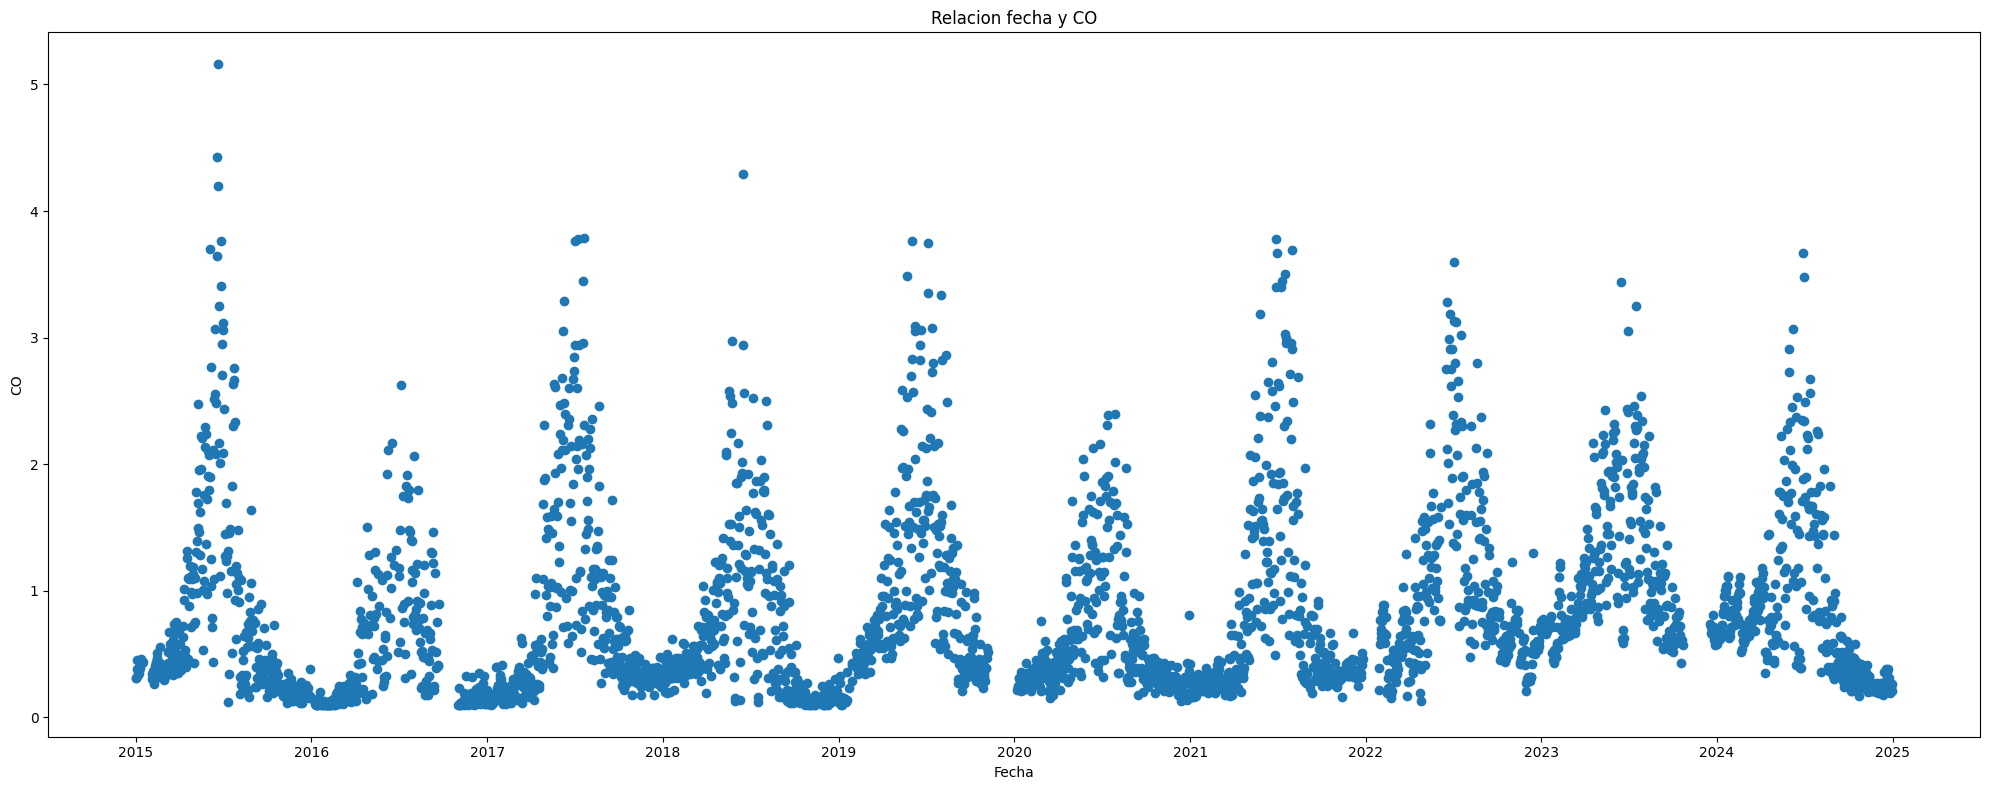

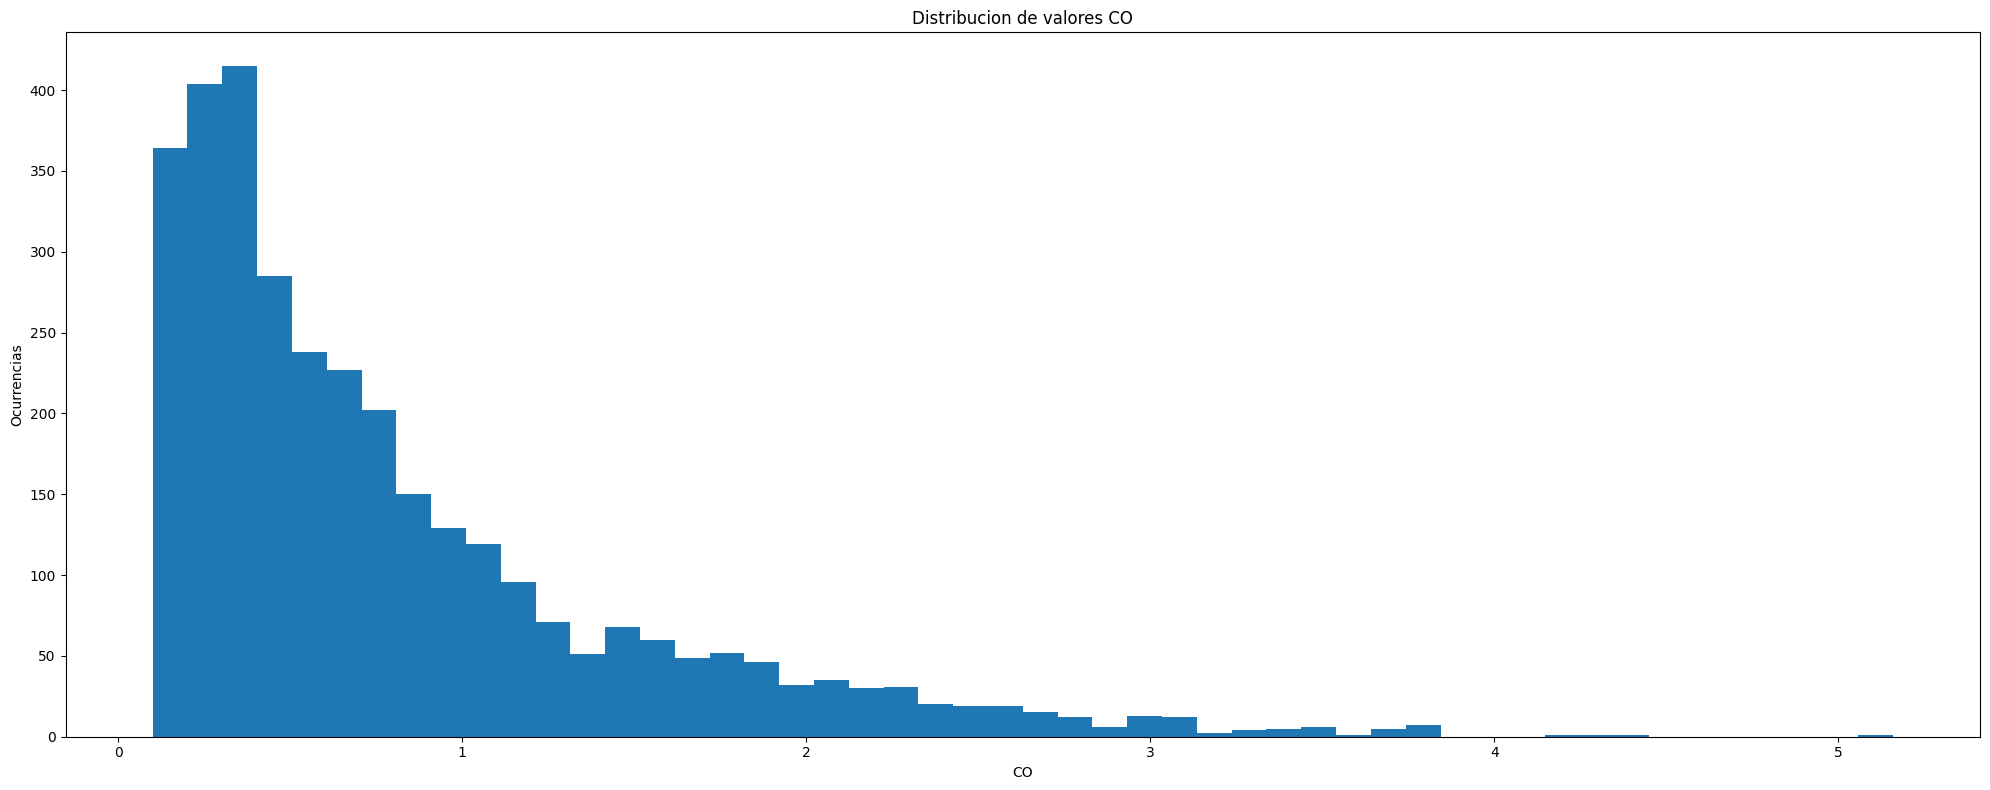

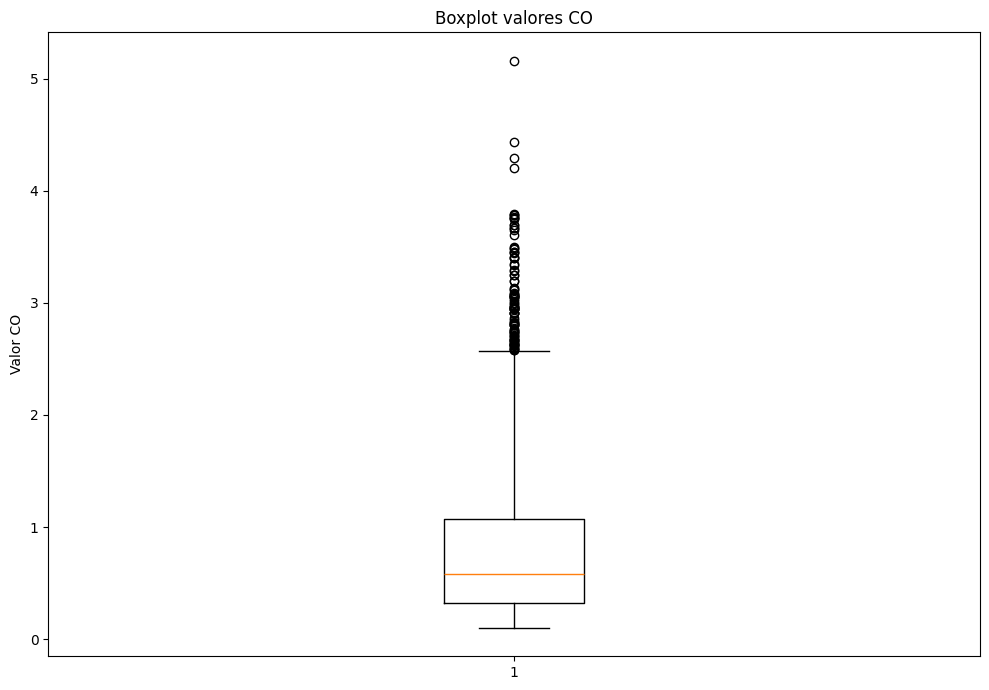

In [ ]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y CO')
plt.scatter(dfnavia['Fecha'], dfnavia['CO'])
plt.xlabel('Fecha')
plt.ylabel('CO')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores CO')
plt.hist(dfnavia['CO'], bins=50)
plt.xlabel('CO')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores CO')
plt.boxplot(dfnavia['CO'].dropna(), whis=2)
plt.ylabel('Valor CO')


plt.tight_layout()
plt.show()


Con esto nos damos cuenta de algo que profundizaremos en un analisis por separadomas adelante.

- Los valores suben drásticamente alrededor de la mitad del año.

Además,

- La mayoría de los valores están entre 0 y 1, pero suben alrededor de esa época del año.


### Análisis MP

#### MP 10

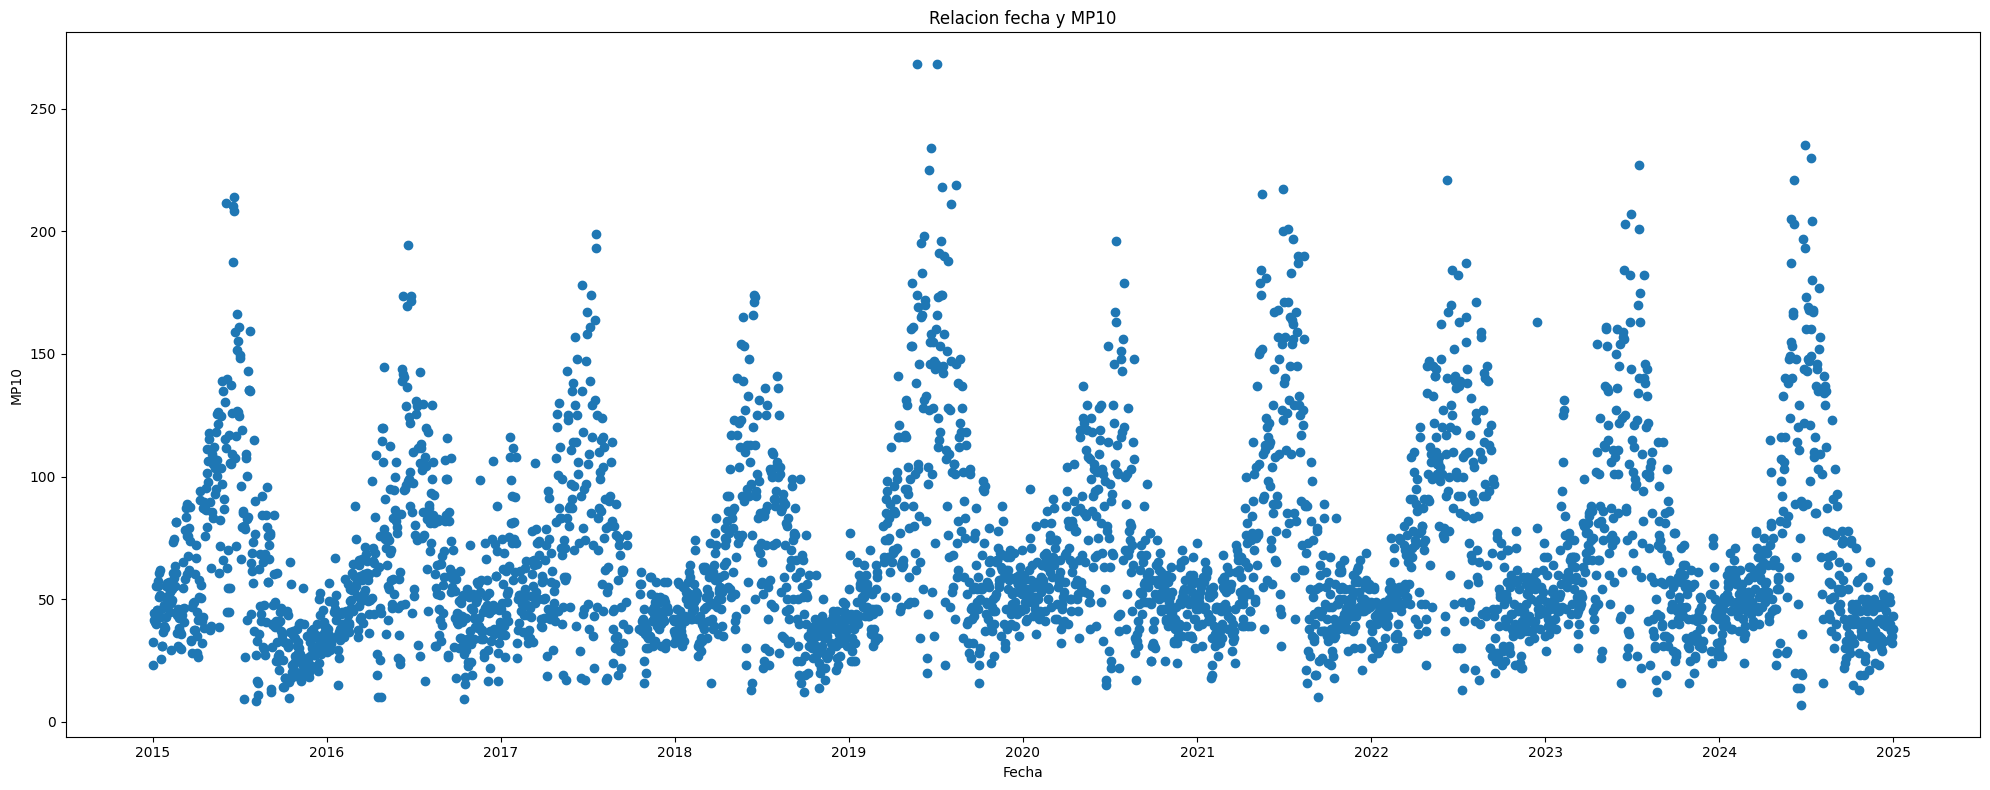

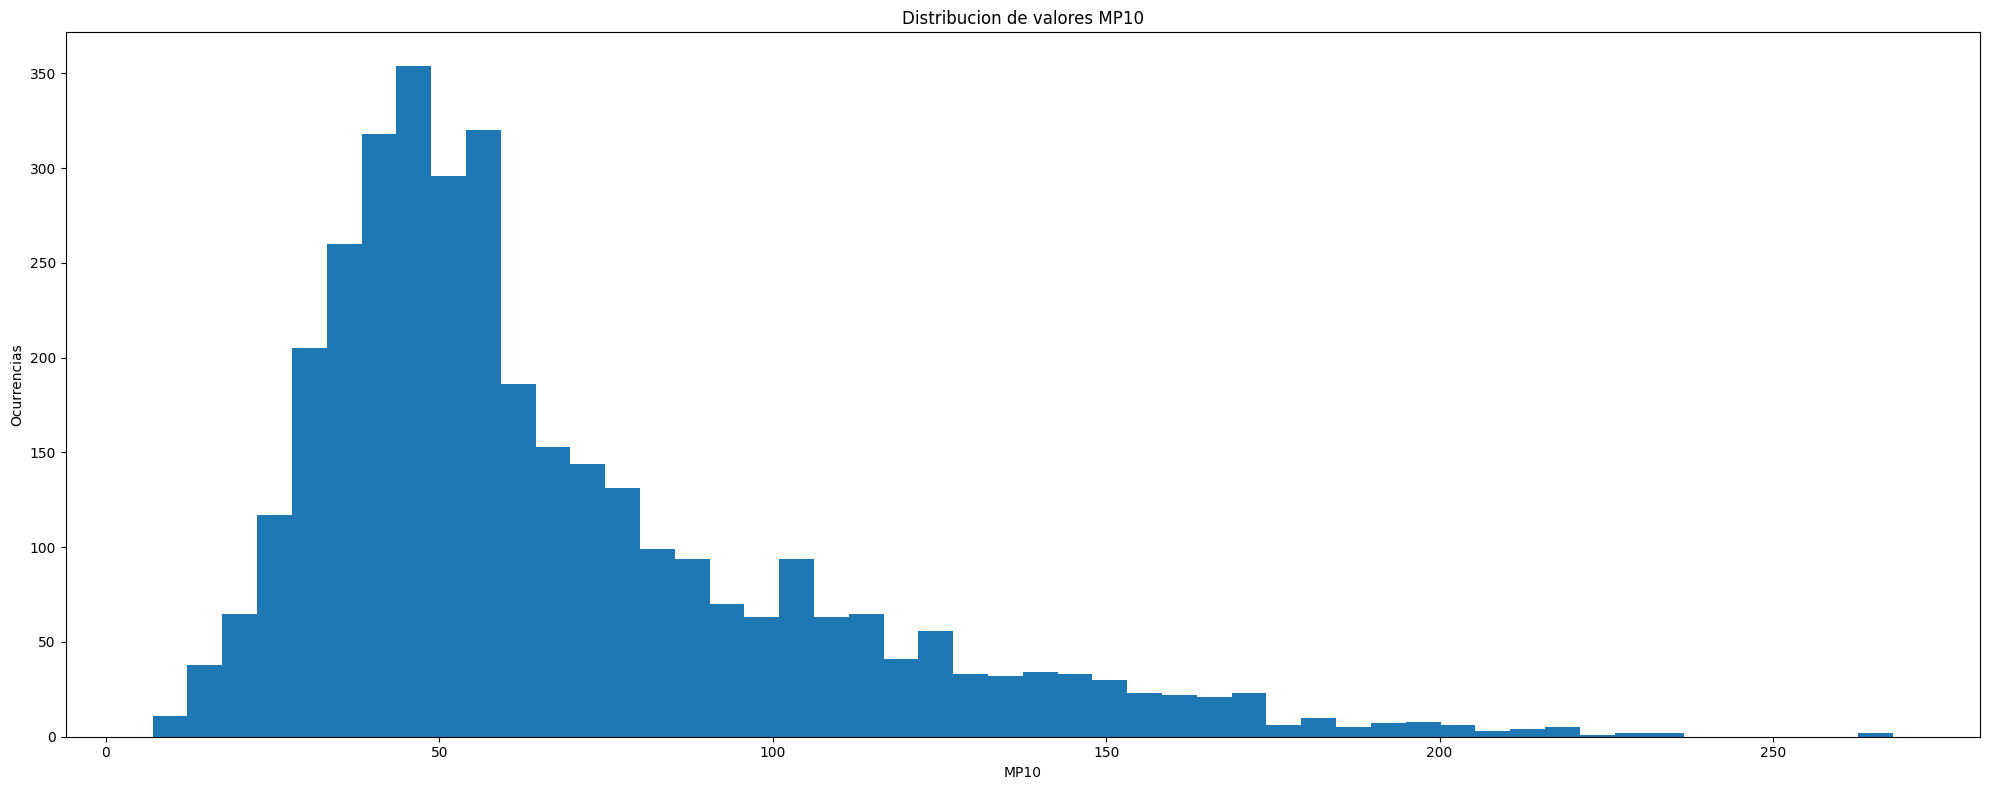

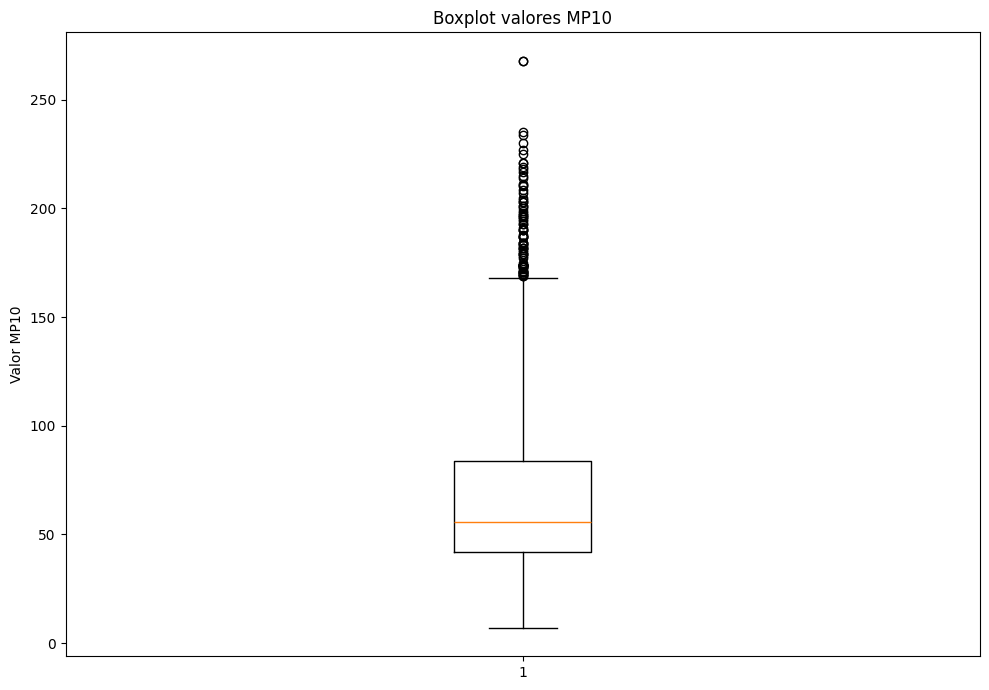

In [ ]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y MP10')
plt.scatter(dfnavia['Fecha'], dfnavia['MP10'])
plt.xlabel('Fecha')
plt.ylabel('MP10')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores MP10')
plt.hist(dfnavia['MP10'], bins=50)
plt.xlabel('MP10')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores MP10')
plt.boxplot(dfnavia['MP10'].dropna(), whis=2)
plt.ylabel('Valor MP10')


plt.tight_layout()
plt.show()


#### MP 2.5

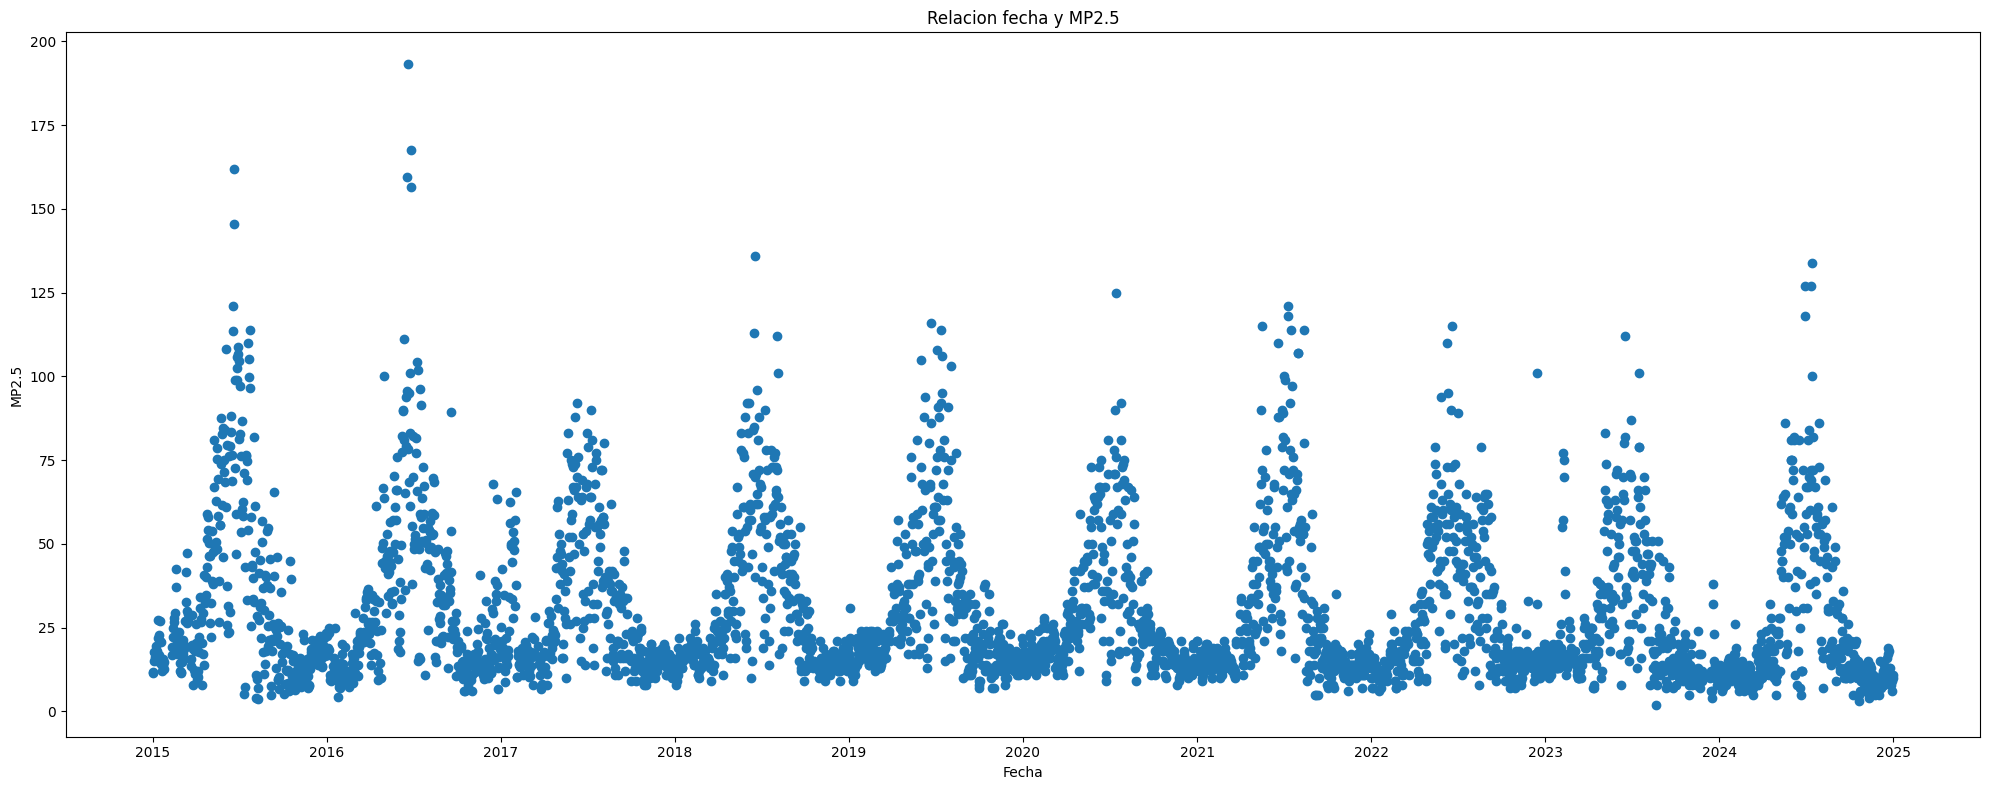

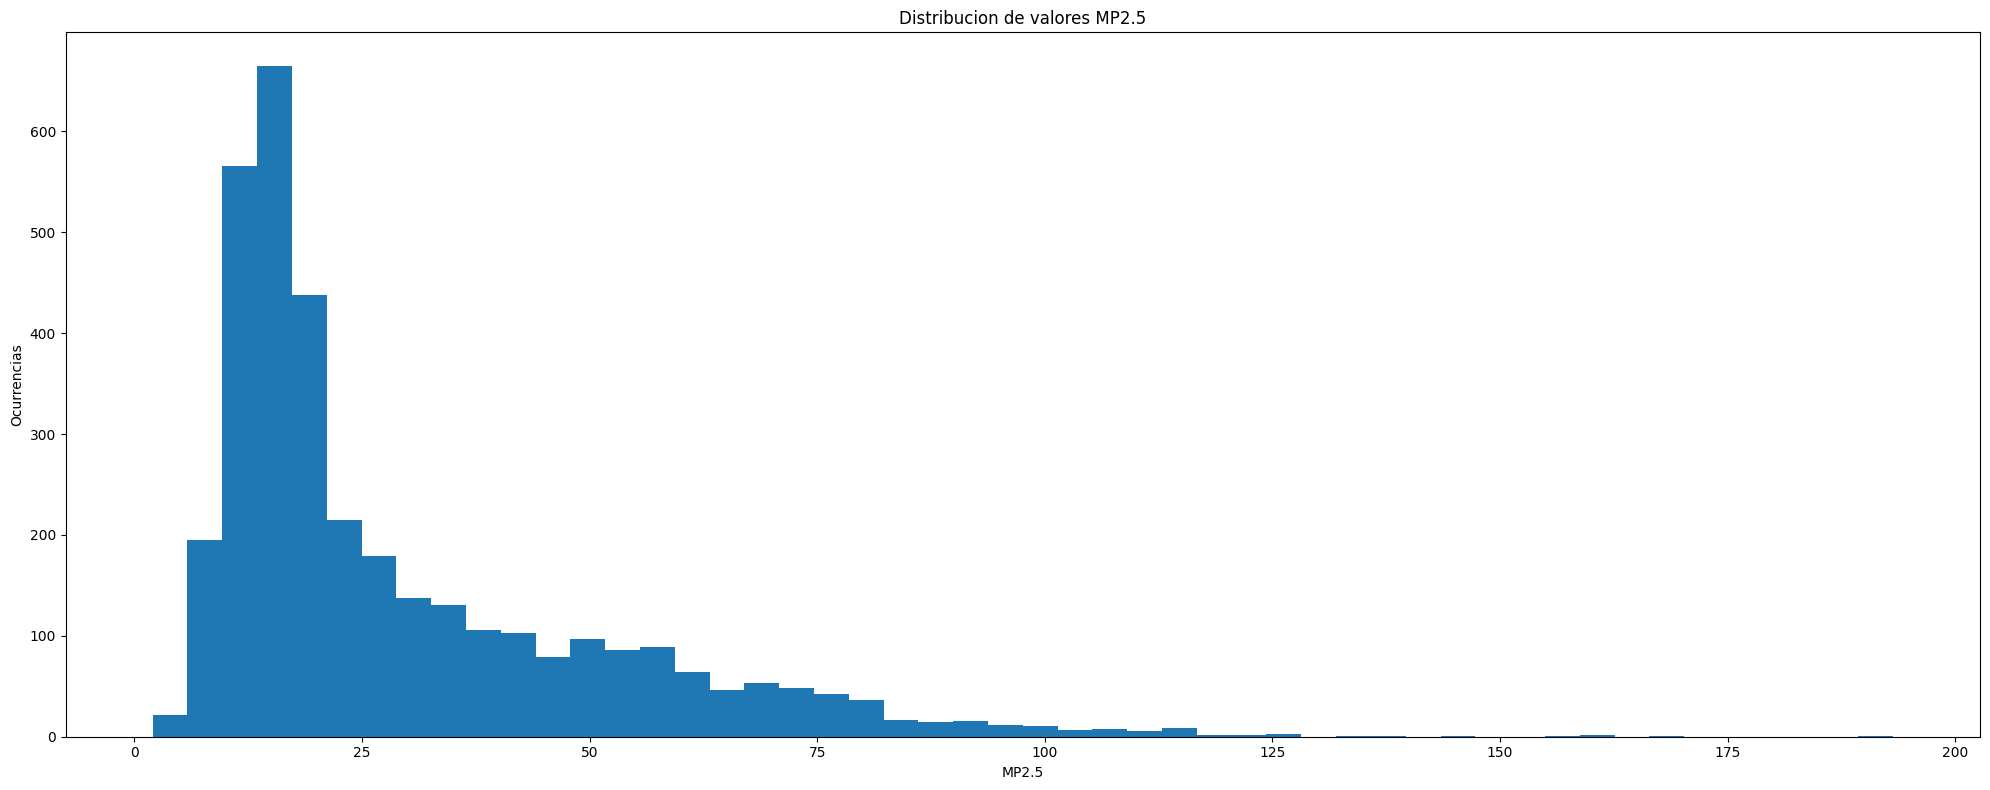

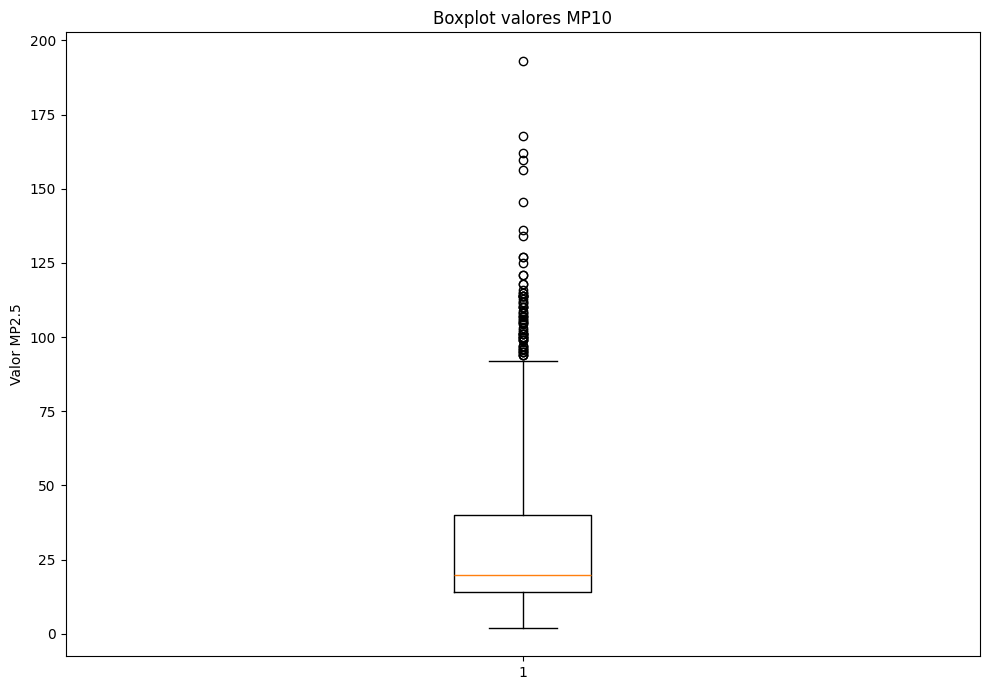

In [ ]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y MP2.5')
plt.scatter(dfnavia['Fecha'], dfnavia['MP2.5'])
plt.xlabel('Fecha')
plt.ylabel('MP2.5')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores MP2.5')
plt.hist(dfnavia['MP2.5'], bins=50)
plt.xlabel('MP2.5')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores MP2.5')
plt.boxplot(dfnavia['MP2.5'].dropna(), whis=2)
plt.ylabel('Valor MP2.5')


plt.tight_layout()
plt.show()


Relativamente los mismos resultados, pero esta vez, los valores se acercan a un límite superior mucho más que en el caso del CO.

### Análisis NO2, NOx, NO

#### NO2

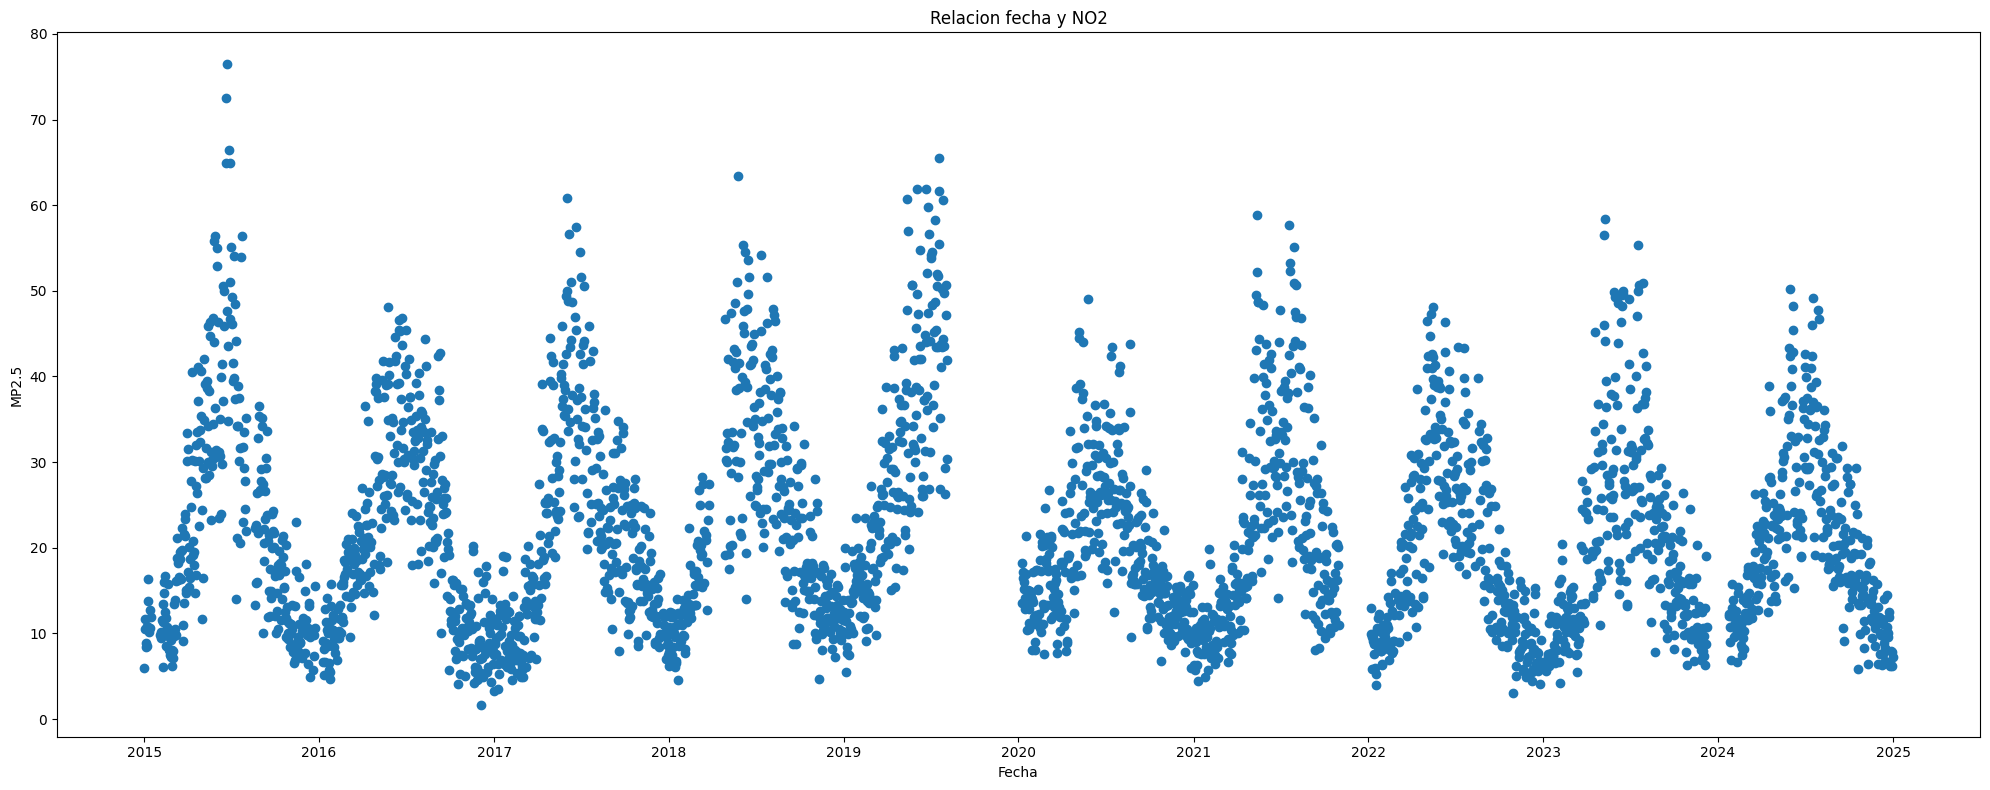

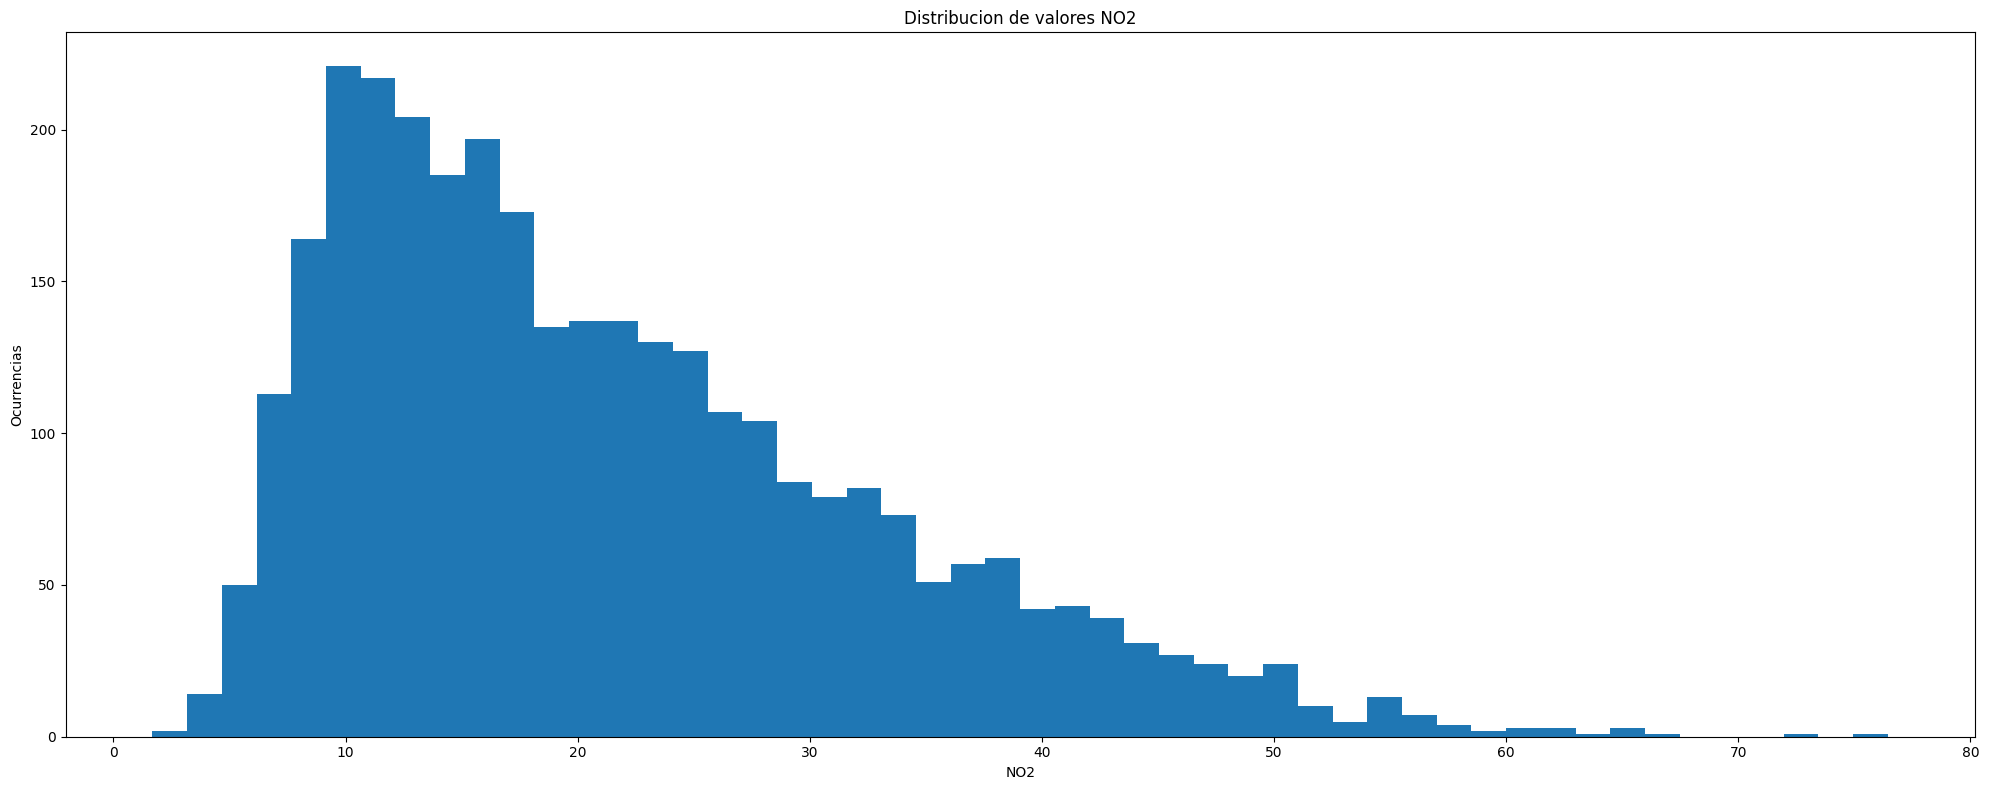

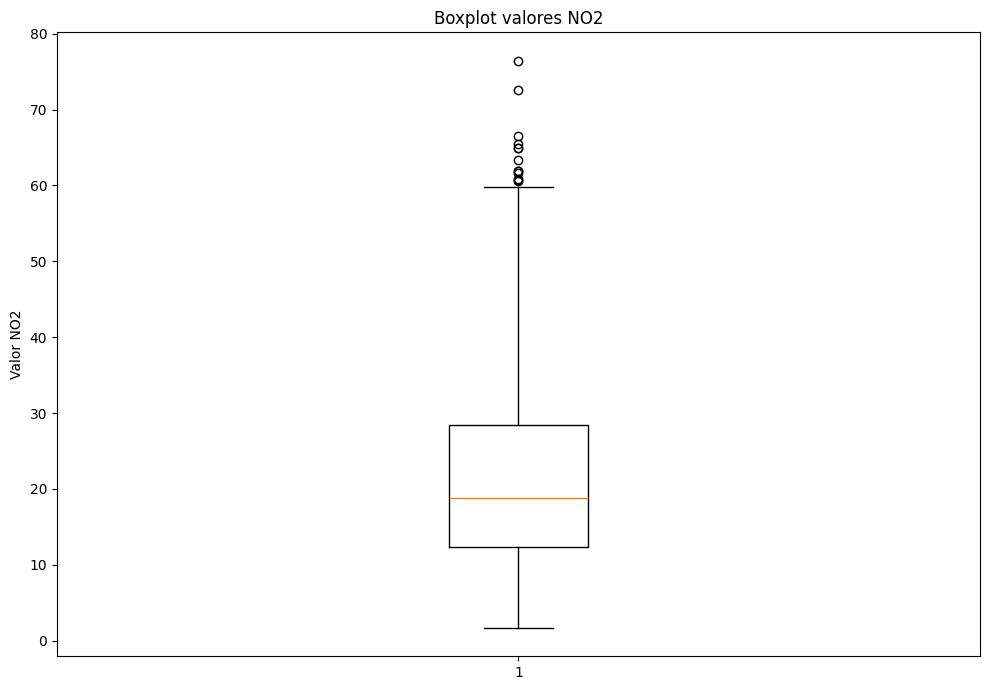

In [ ]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y NO2')
plt.scatter(dfnavia['Fecha'], dfnavia['NO2'])
plt.xlabel('Fecha')
plt.ylabel('NO2')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores NO2')
plt.hist(dfnavia['NO2'], bins=50)
plt.xlabel('NO2')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores NO2')
plt.boxplot(dfnavia['NO2'].dropna(), whis=2)
plt.ylabel('Valor NO2')


plt.tight_layout()
plt.show()


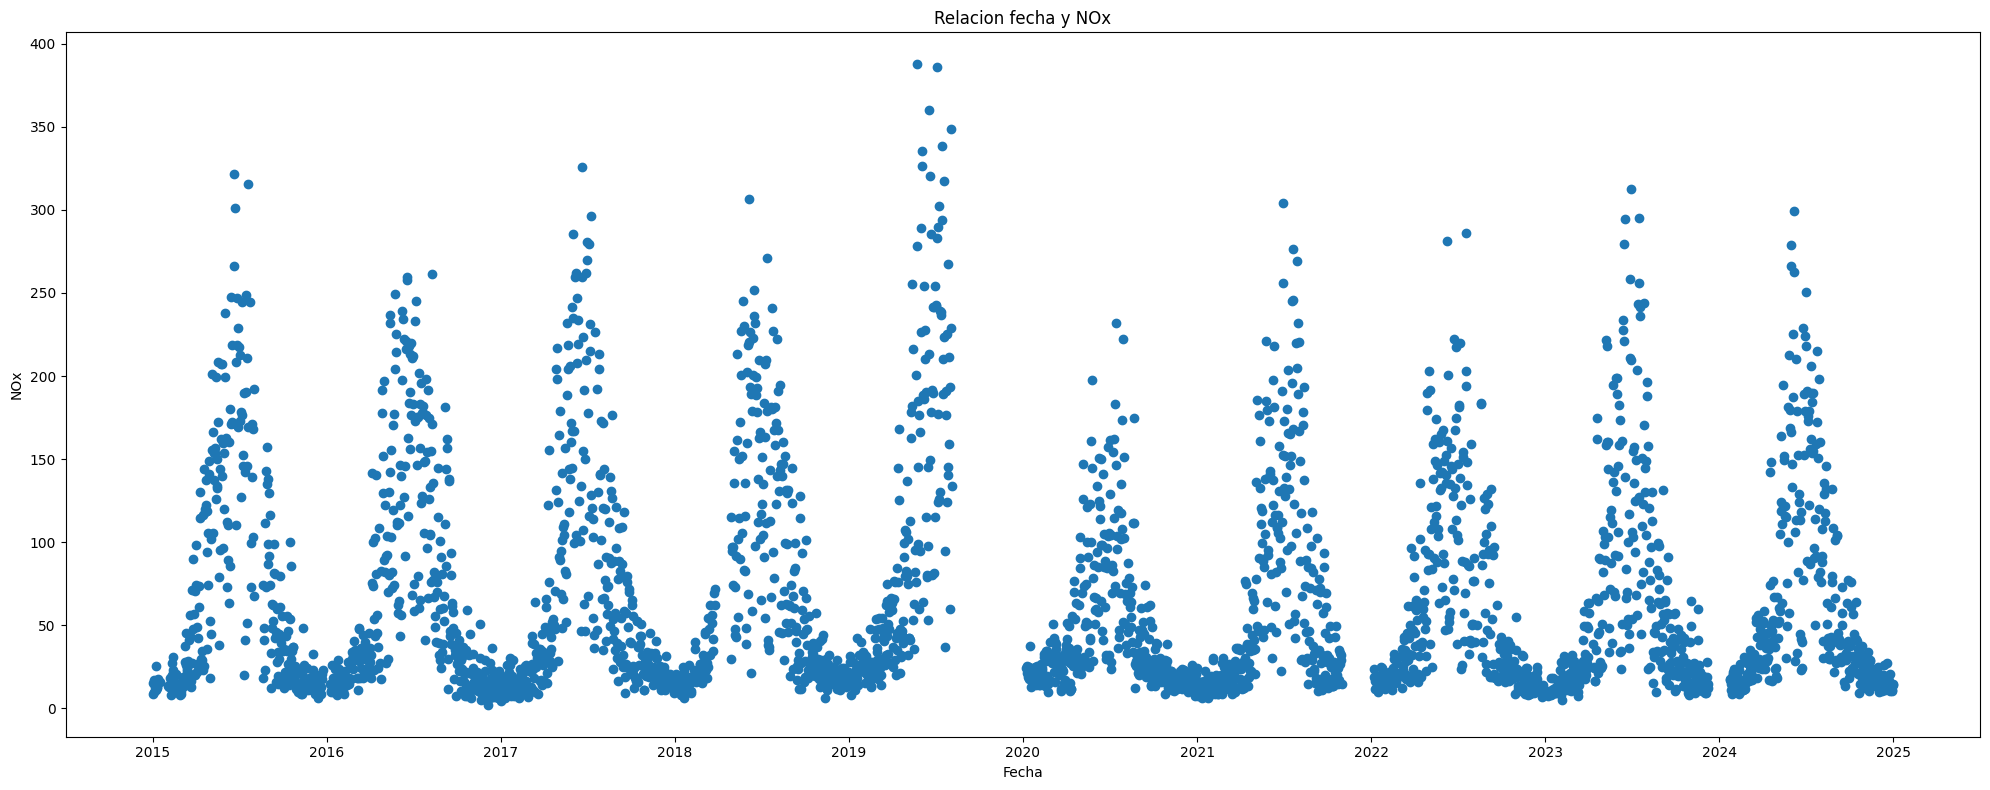

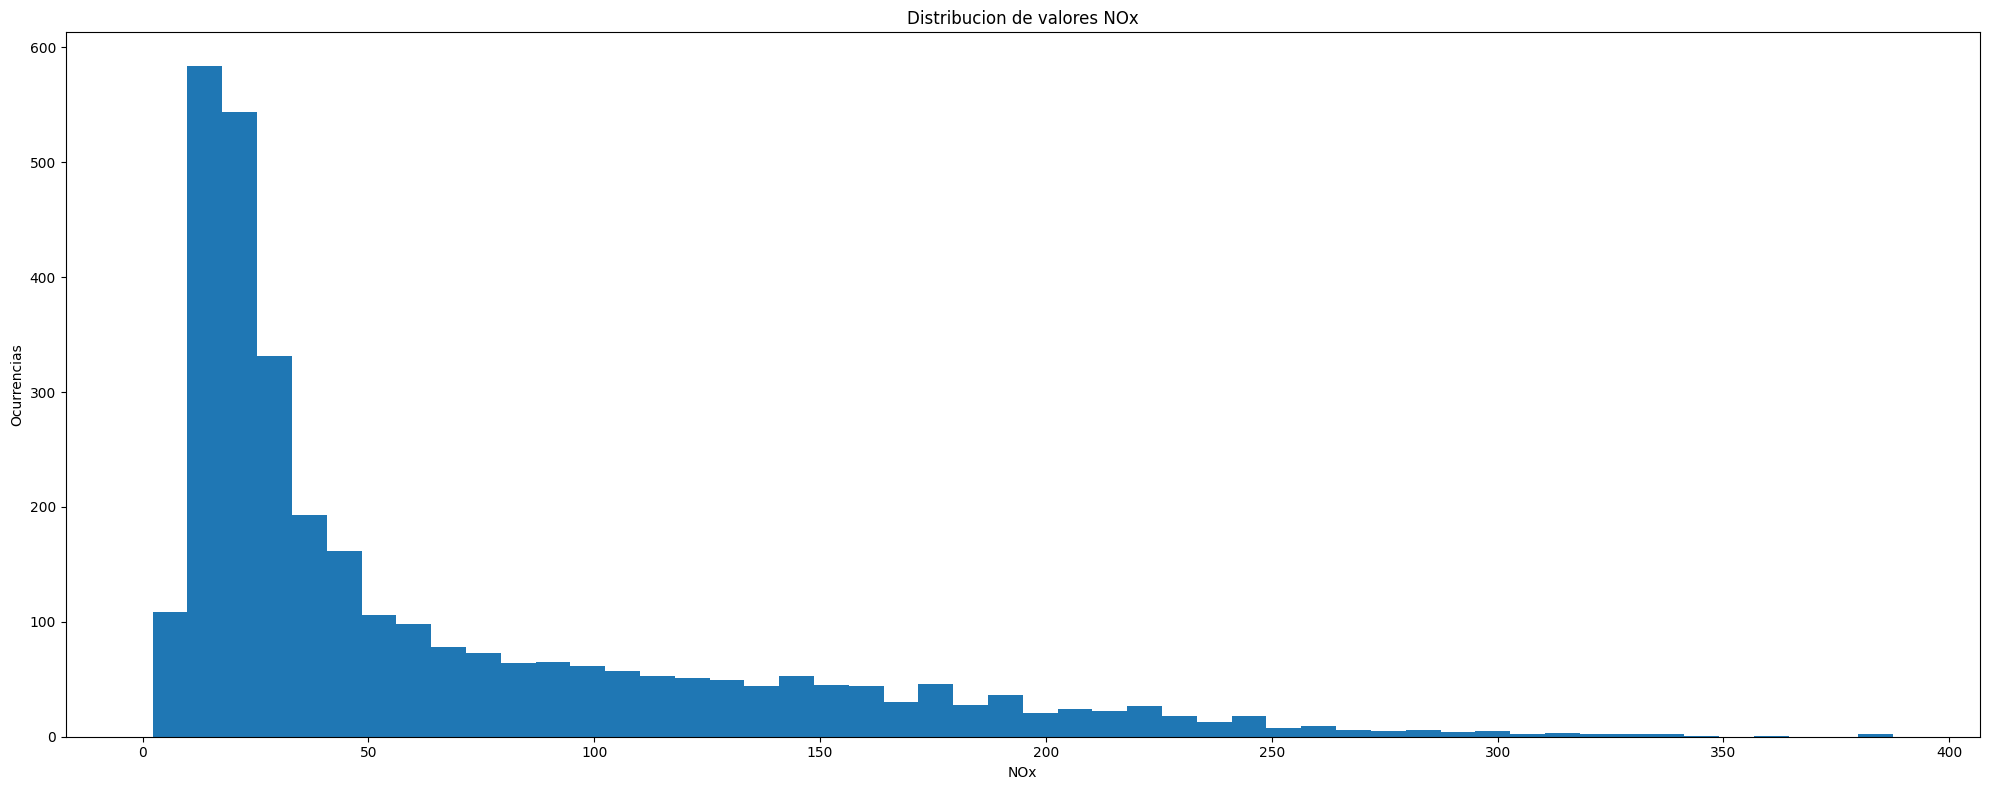

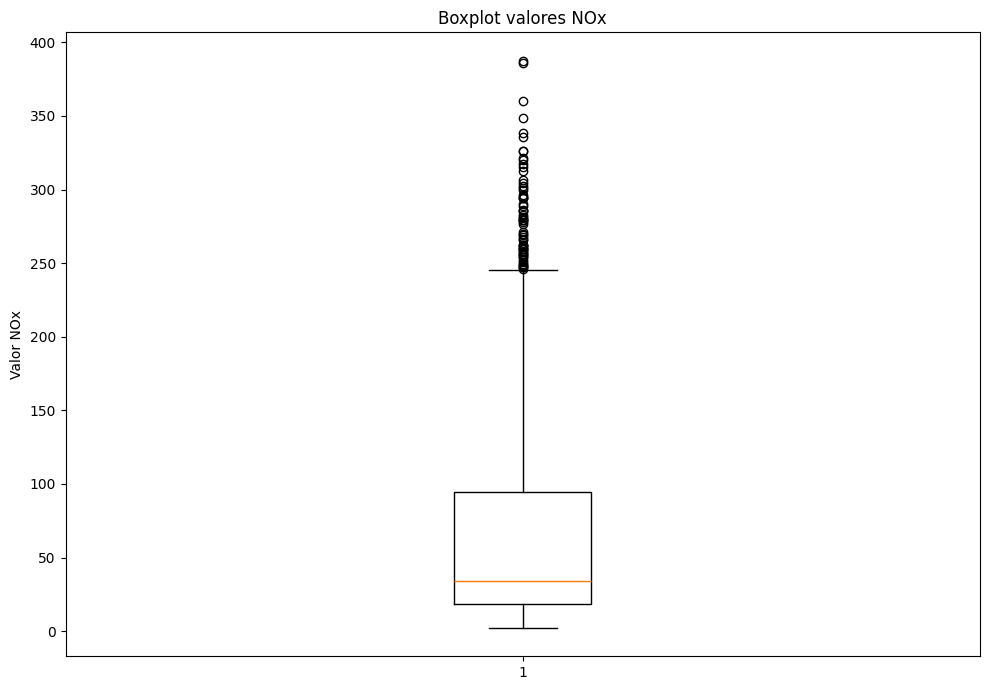

In [269]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y NOx')
plt.scatter(dfnavia['Fecha'], dfnavia['NOx'])
plt.xlabel('Fecha')
plt.ylabel('NOx')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores NOx')
plt.hist(dfnavia['NOx'], bins=50)
plt.xlabel('NOx')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores NOx')
plt.boxplot(dfnavia['NOx'].dropna(), whis=2)
plt.ylabel('Valor NOx')


plt.tight_layout()
plt.show()


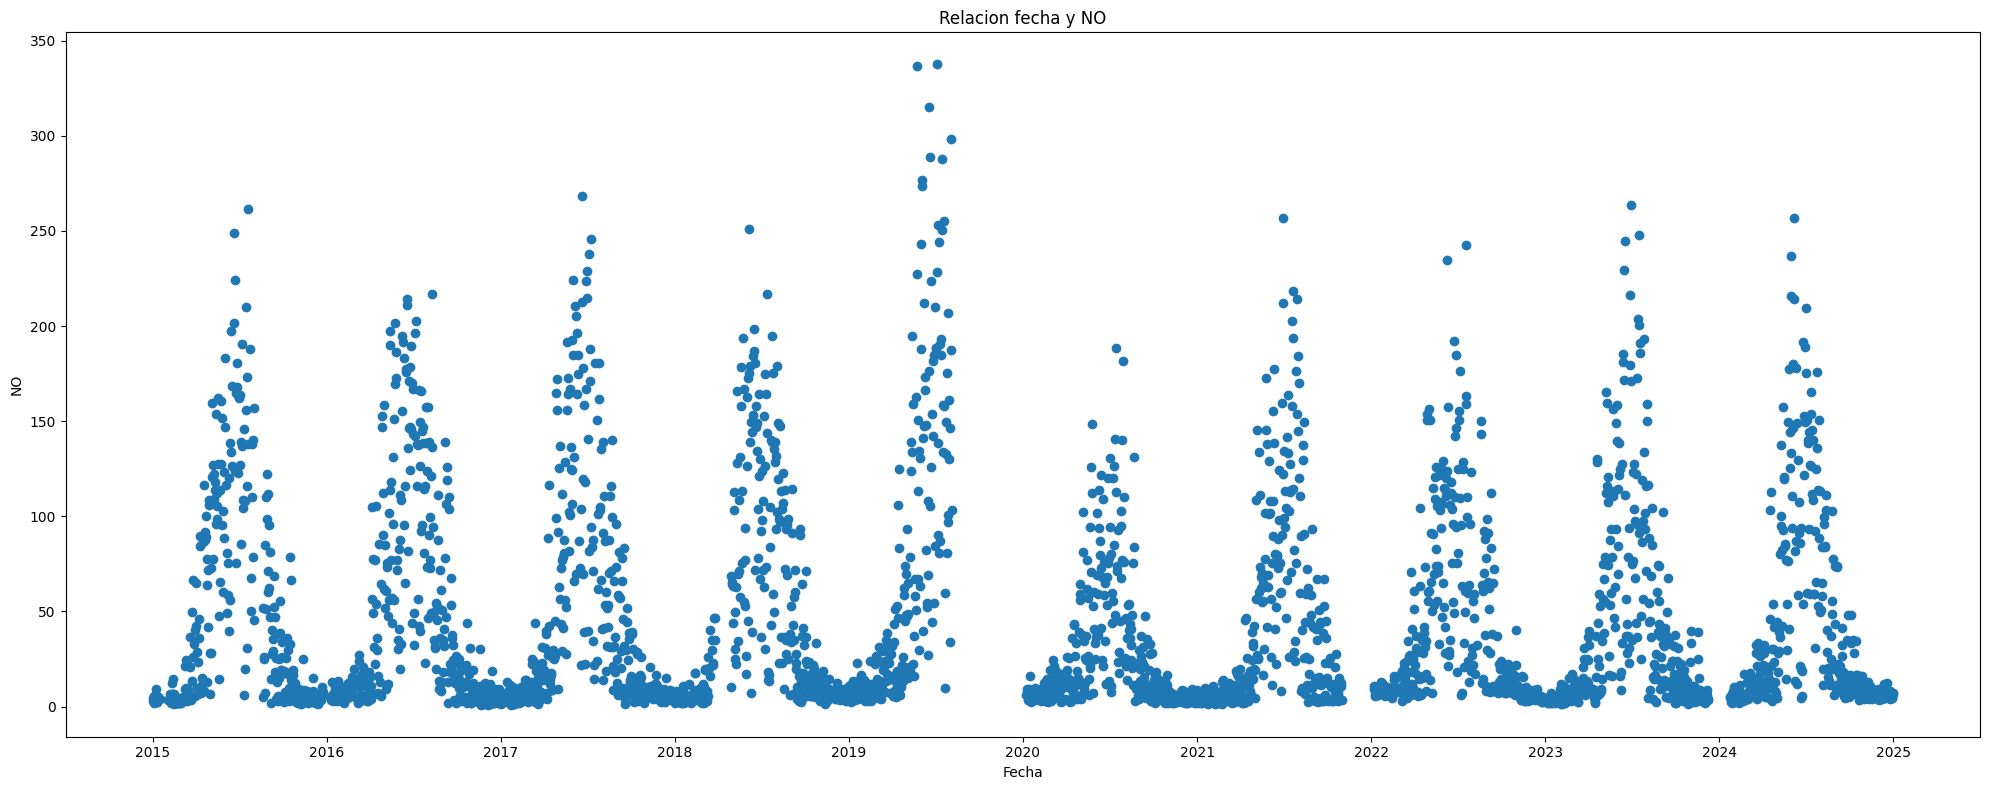

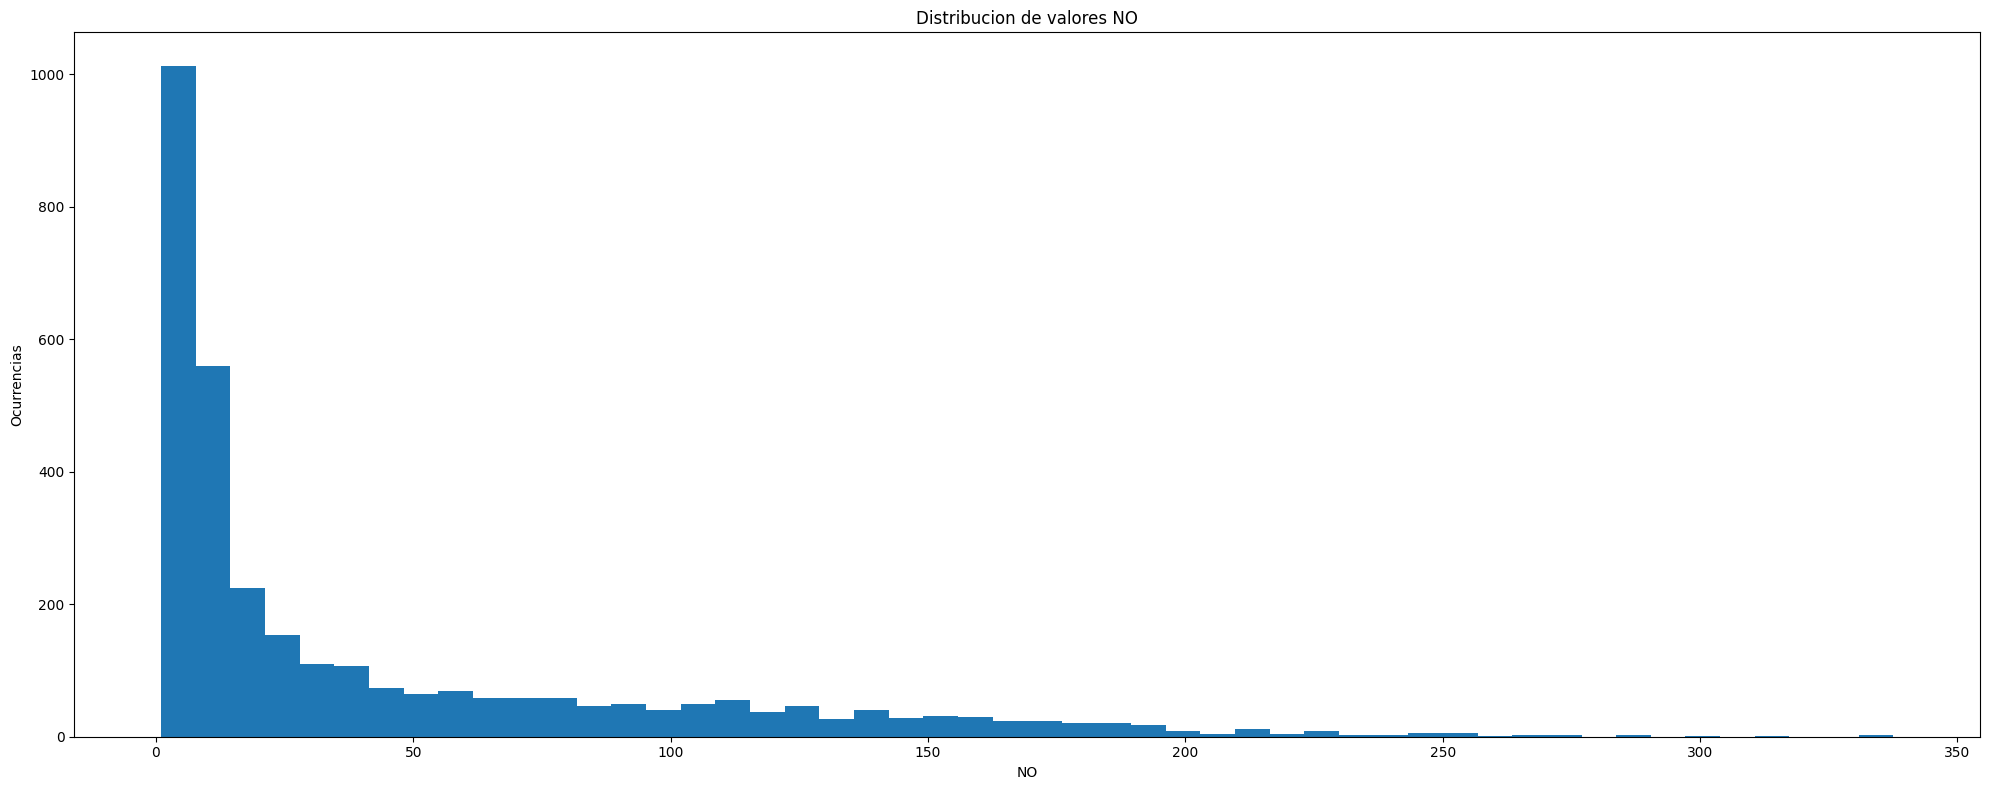

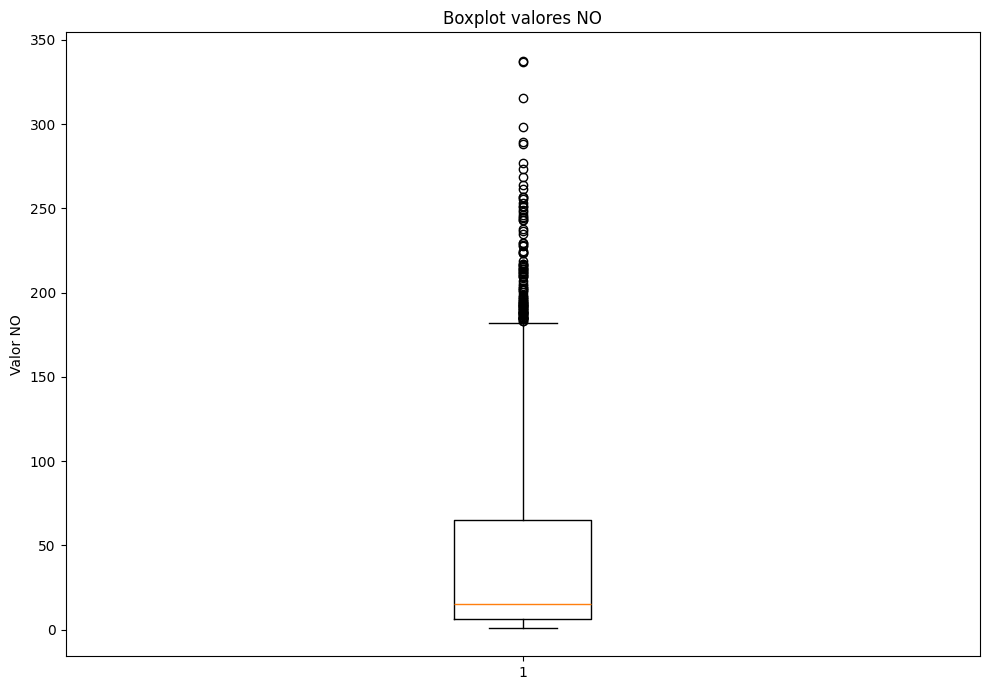

In [270]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y NO')
plt.scatter(dfnavia['Fecha'], dfnavia['NO'])
plt.xlabel('Fecha')
plt.ylabel('NO')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores NO')
plt.hist(dfnavia['NO'], bins=50)
plt.xlabel('NO')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores NO')
plt.boxplot(dfnavia['NO'].dropna(), whis=2)
plt.ylabel('Valor NO')


plt.tight_layout()
plt.show()


Se repiten los patrones de elevaciones repentinas en la mitad del año, pero esta vez, tenemos algunas diferencias entre las distribuciones de NO, NOx y NO2.

Principalmente:
- NO y NOx son relativamente similares, con NO2 teniendo valores más hacia la parte superior del dataset.
- Podemos ver esto a nivel superficial en el histograma y mas concretamente en el boxplot.

#### Análisis O3

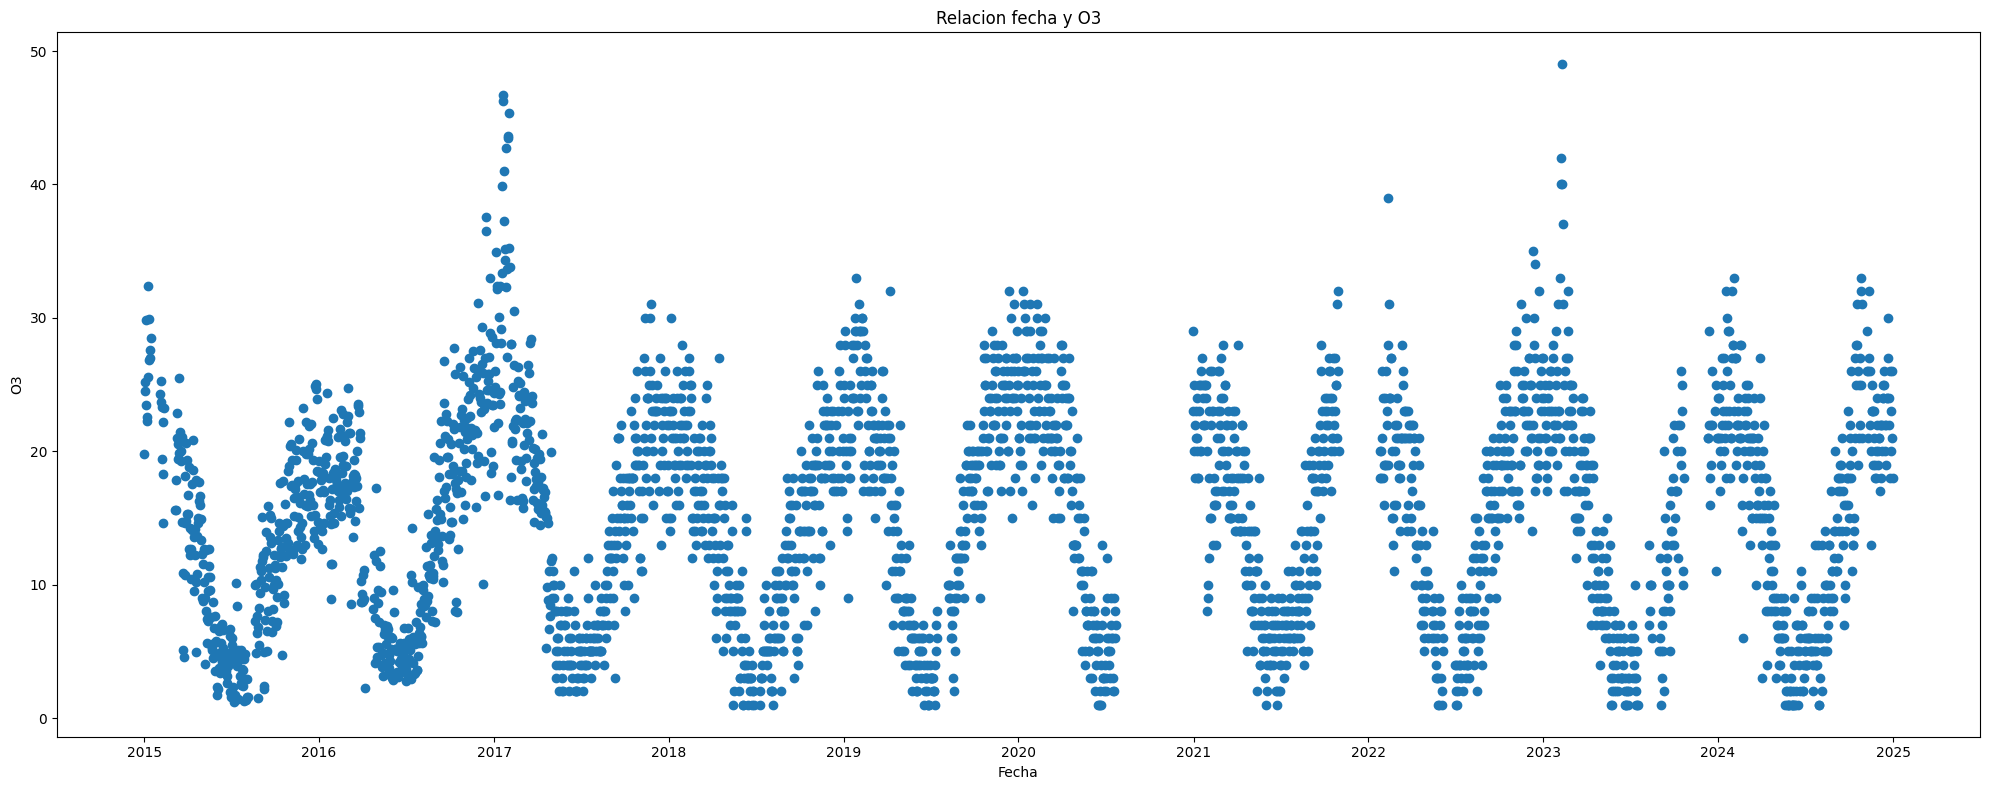

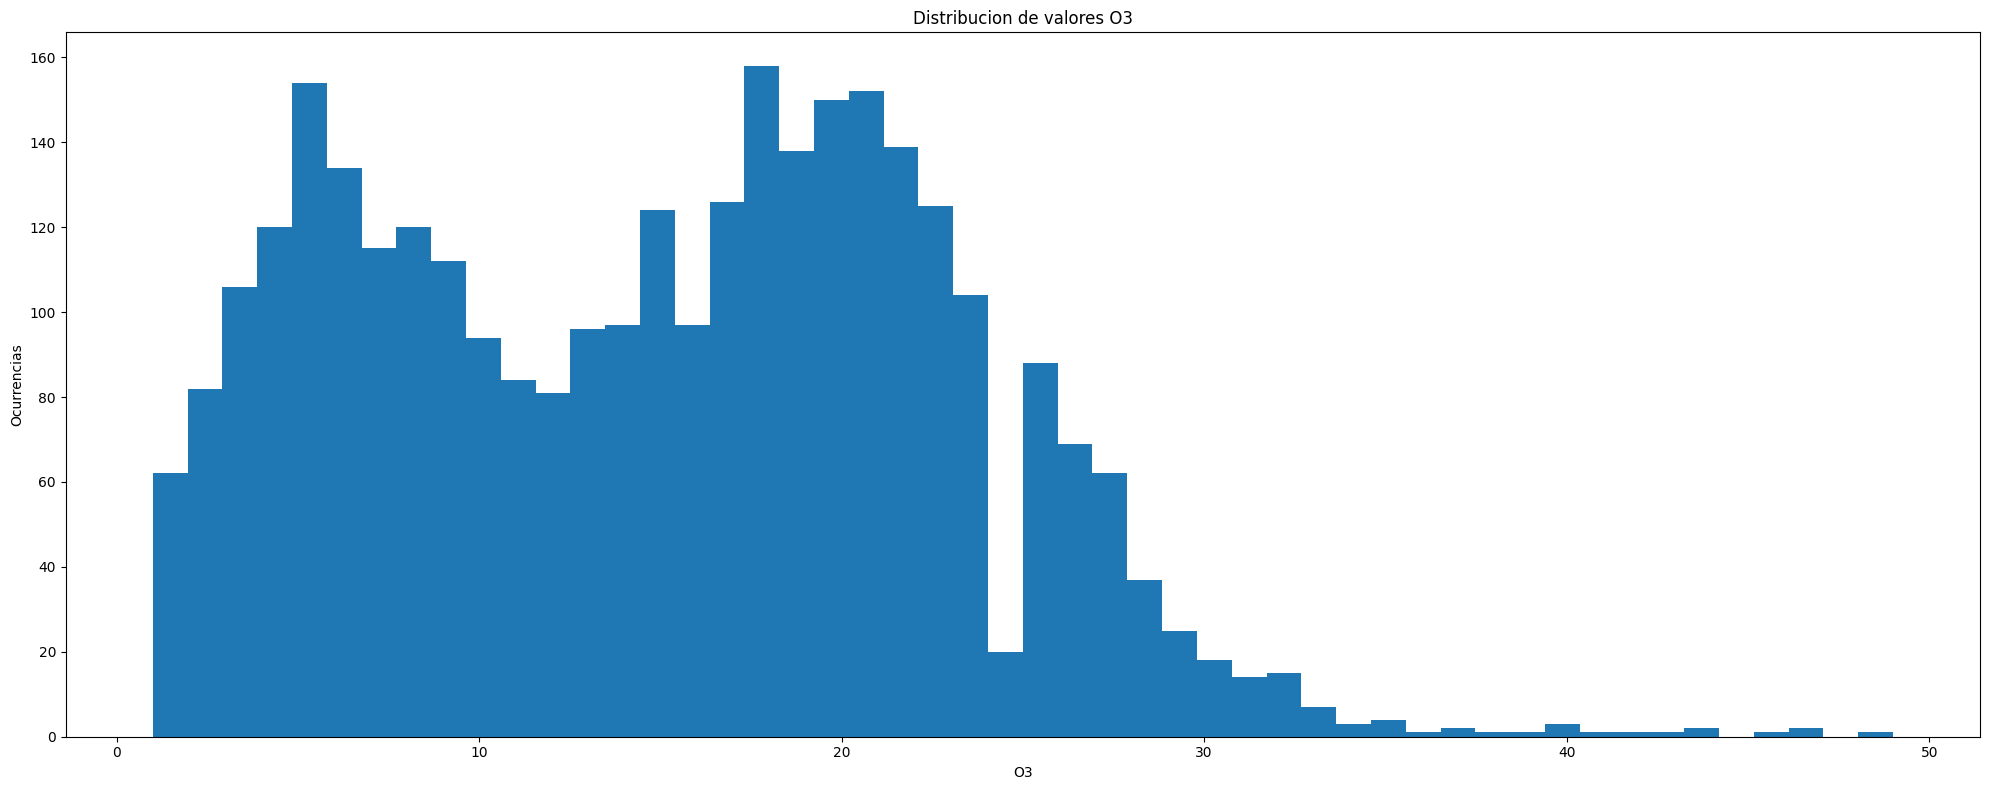

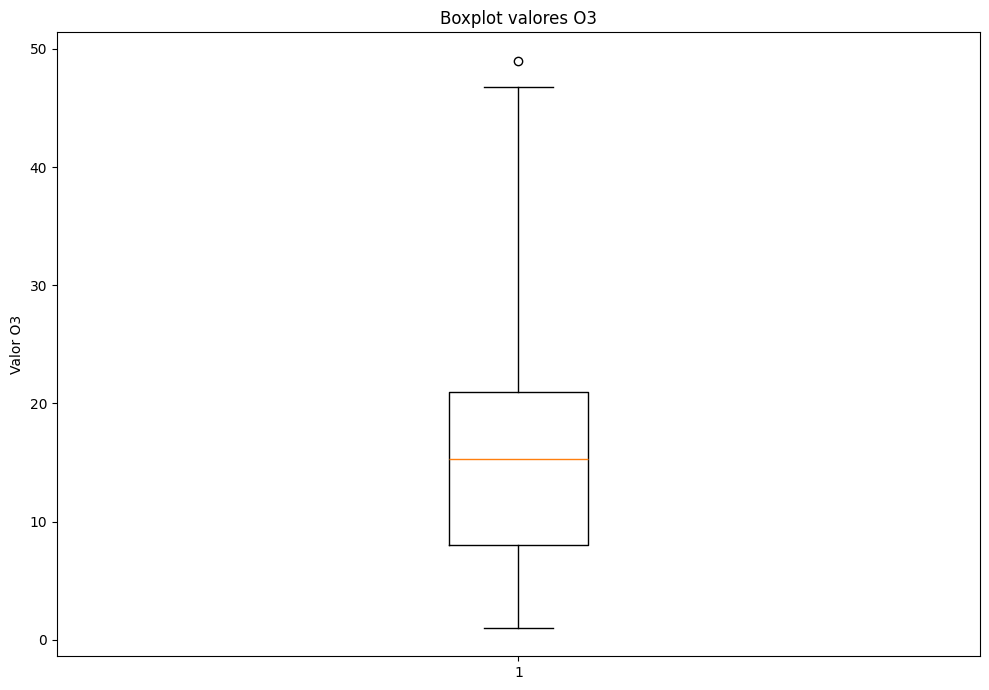

In [271]:
# Grafico de dispersión
plt.figure(figsize=(20, 8))
plt.title('Relacion fecha y O3')
plt.scatter(dfnavia['Fecha'], dfnavia['O3'])
plt.xlabel('Fecha')
plt.ylabel('O3')

plt.tight_layout()
plt.show()
# Histograma
plt.figure(figsize=(20, 8))
plt.title('Distribucion de valores O3')
plt.hist(dfnavia['O3'], bins=50)
plt.xlabel('O3')
plt.ylabel('Ocurrencias')

plt.tight_layout()
plt.show()
# Boxplot
plt.figure(figsize=(10, 7))
plt.title('Boxplot valores O3')
plt.boxplot(dfnavia['O3'].dropna(), whis=2)
plt.ylabel('Valor O3')


plt.tight_layout()
plt.show()


Este caso es muy diferente de los anteriores.
- Los valores estan distribuidos de una manera mucho mas uniforme hasta un cierto punto.
- La repentina subida de valores en la mitad del año es mucho mas gradual que con las otras variables.
- La mediana está casi justo al medio de Q3 y Q1, a diferencia de las otras variables, donde estaba mucho mas cerca a Q1.